# Face Recognition con SVD: Olivetti vs Labeled Faces in the Wild

Questo notebook mette a confronto due pipeline complete di riconoscimento facciale, applicate su due dataset con caratteristiche molto diverse tra loro:

- **Dataset Olivetti**: 400 immagini in scala di grigi, 40 persone diverse, sfondo neutro uniforme, risoluzione 64×64 pixel
- **Dataset LFW (Labeled Faces in the Wild)**: immagini raccolte "in the wild" — illuminazione variabile, pose diverse, sfondo eterogeneo

L'obiettivo è quantificare l'impatto della variabilità del dato sulla performance di un approccio lineare interpretabile (Eigenfaces + classificatore supervisionato).

---

## Pipeline operativa

Entrambe le pipeline seguono lo stesso flusso operativo:

1. Caricamento e pre-processing dei dati
2. Centratura e decomposizione SVD
3. Selezione automatica delle componenti ottimali
4. Riduzione dimensionale e ricostruzione
5. Confronto tra classificatori: KNN e varianti SVM
6. Rilevamento di volti sconosciuti tramite soglia sulle distanze
7. Cross-validation e analisi degli errori
8. Confronto finale tra i due dataset

---

## Fondamenti Teorici

### Singular Value Decomposition (SVD)

La SVD scompone una matrice $X \in \mathbb{R}^{m \times n}$ nel prodotto di tre matrici:

$$X = U \Sigma V^T$$

dove:
- $U \in \mathbb{R}^{m \times m}$: colonne ortogonali chiamate **vettori singolari sinistri** — rappresentano le coordinate di ogni immagine nello spazio ridotto
- $\Sigma \in \mathbb{R}^{m \times n}$: matrice diagonale dei **valori singolari** $\sigma_1 \geq \sigma_2 \geq \ldots \geq 0$, in ordine decrescente di importanza
- $V^T \in \mathbb{R}^{n \times n}$: righe ortogonali chiamate **vettori singolari destri**, visualizzabili come eigenfaces

Nella pipeline, la SVD completa viene calcolata tramite `numpy.linalg.svd` esclusivamente per l'analisi dell'energia cumulativa. La riduzione dimensionale vera e propria è affidata a `TruncatedSVD` di scikit-learn, che calcola solo le prime $k$ componenti in modo efficiente.

L'**energia** catturata dalle prime $k$ componenti si misura come:

$$E_k = \frac{\sum_{i=1}^{k} \sigma_i^2}{\sum_{i=1}^{n} \sigma_i^2}$$

Selezionando il minimo $k$ tale che $E_k \geq 0.95$, si preserva il 95% della varianza del dataset riducendo drasticamente la dimensionalità.


### Eigenfaces

Le componenti apprese da `TruncatedSVD` (accessibili come `svd_model.components_`) rappresentano le **eigenfaces**, ovvero le direzioni principali di variazione del dataset.

Ogni volto può essere espresso come combinazione lineare delle prime $k$ eigenfaces:

$$x \approx \bar{x} + \sum_{i=1}^{k} \alpha_i v_i$$

dove:
- $\bar{x}$ è il volto medio,
- $v_i$ sono le eigenfaces,
- $\alpha_i$ sono le coordinate del volto nello spazio ridotto.

In questo modo, ogni immagine viene rappresentata da un vettore compatto di coefficienti: una vera e propria "firma" nello spazio latente.

#### Ricostruzione

Dato il vettore ridotto $z \in \mathbb{R}^k$, il volto originale viene ricostruito come:

$$\hat{x} = z \cdot V^T_k + \bar{x}$$

dove $V^T_k$ è la matrice delle prime $k$ eigenfaces (`svd_model.components_`). L'errore di ricostruzione per campione è misurato tramite MSE.


### Centratura dei Dati

Prima di applicare la SVD, si sottrae il **volto medio** $\bar{x}$ a ogni immagine:

$$X_{\text{centered}} = X - \bar{x}$$

Questo garantisce che la decomposizione catturi le *differenze* tra i volti, non la loro posizione assoluta nello spazio delle feature. Senza centratura, la prima componente descriverebbe semplicemente il valore medio dei pixel, non la struttura discriminante del dataset.


### K-Nearest Neighbors (KNN)

Il KNN assegna a un nuovo campione l'etichetta del vicino più prossimo nello spazio ridotto. Nel caso $k=1$ (default della pipeline), la decisione è puramente locale:

$$\hat{y} = y_{i^*}, \quad i^* = \arg\min_i d(z,\, z_i)$$

dove $z$ è la proiezione del volto nello spazio SVD e $d$ è la **distanza di Manhattan** (impostazione di default):

$$d(z, z_i) = \sum_{j=1}^{k} |z_j - z_{i,j}|$$

La pipeline supporta anche la ricerca degli iperparametri ottimali (metrica, numero di vicini, schema di pesatura) tramite `GridSearchCV`.

**Vantaggi:**
- Modello semplice e non parametrico
- Nessuna fase di training complessa
- Efficace in spazi a bassa dimensionalità ben separati

**Limiti:**
- Sensibile alla variabilità intra-classe
- Performance degradate quando le distribuzioni delle classi si sovrappongono


### Support Vector Machines (SVM)

L'SVM costruisce un iperpiano che massimizza il margine tra le classi:

$$\min_{w,b} \frac{1}{2}\|w\|^2 + C \sum_i \xi_i$$

Il parametro $C$ regola il compromesso tra ampiezza del margine e penalizzazione degli errori.

#### Kernel Lineare

$$K(x_i, x_j) = x_i^T x_j$$

Efficace quando lo spazio SVD è già quasi linearmente separabile.

#### Kernel RBF

$$K(x_i, x_j) = \exp(-\gamma \|x_i - x_j\|^2)$$

Introduce non linearità e permette frontiere decisionali più flessibili. Nel contesto della riduzione tramite SVD, il kernel lineare risulta spesso competitivo grazie alla struttura compatta dello spazio ridotto.

La pipeline confronta direttamente KNN, SVM lineare e SVM RBF nel metodo `compare_classifiers`, misurando accuracy e tempo di addestramento per ciascun classificatore.


### Cross-Validation Stratificata

Per stimare la robustezza dei modelli, la pipeline adotta una **k-fold stratificata** (`StratifiedKFold`, $k=5$): ogni fold mantiene le proporzioni originali delle classi, evitando squilibri nei subset di validazione. Per ogni fold si calcola l'accuracy, e il risultato finale è riportato come media ± deviazione standard con relativo intervallo di confidenza a $2\sigma$.


### Rilevamento di Volti Sconosciuti

Per individuare volti non presenti nel training set, si calcola la distanza euclidea minima tra il campione da classificare e tutti i campioni del training nello spazio SVD:

$$d_{\min} = \min_i \| z - z_i^{\text{train}} \|$$

Se $d_{\min} > \theta$, il volto viene classificato come **UNKNOWN**.

La soglia $\theta$ viene stimata automaticamente sul validation set come:

$$\theta = \mu_d + 2\,\sigma_d$$

dove $\mu_d$ e $\sigma_d$ sono rispettivamente media e deviazione standard delle distanze minime osservate. Questo criterio garantisce che solo i campioni geometricamente molto lontani dalla distribuzione nota vengano rifiutati, introducendo una forma semplice ma efficace di **open-set recognition**.

## Metriche di Valutazione dei Classificatori

Prima di confrontare KNN e SVM, è importante definire con precisione le metriche utilizzate per determinare il "classificatore migliore" — sia sul dataset originale (pre-SVD) che su quello ridotto (post-SVD).

### Accuracy

La metrica principale usata nella pipeline è l'**accuracy**:

$$\text{Accuracy} = \frac{\text{Predizioni corrette}}{\text{Totale campioni}}$$

È intuitiva e adatta quando le classi sono bilanciate. Su Olivetti (10 immagini per persona) il bilanciamento è perfetto; su LFW il bilanciamento è meno omogeneo (da 60 a 530 immagini per soggetto), il che rende l'accuracy potenzialmente ottimistica per le classi più rappresentate.

### Classification Report: Precision, Recall, F1

Il classification report restituisce per ogni classe tre metriche complementari:

| Metrica | Formula | Cosa misura |
|---------|---------|-------------|
| **Precision** | $\frac{TP}{TP+FP}$ | Quante delle predizioni positive sono effettivamente corrette? |
| **Recall** | $\frac{TP}{TP+FN}$ | Quante delle istanze positive reali vengono trovate? |
| **F1-score** | $\frac{2 \cdot P \cdot R}{P + R}$ | Media armonica di precision e recall |

- **TP** = veri positivi, **FP** = falsi positivi, **FN** = falsi negativi

Il **macro-average F1** (media aritmetica degli F1 per classe) è la metrica più equa in presenza di classi sbilanciate, perché assegna lo stesso peso a ogni classe indipendentemente dalla sua frequenza.

Il **weighted-average F1** (media pesata per il numero di campioni per classe) riflette invece le performance ponderate sulla distribuzione reale del test set.

### Criteri di selezione del modello migliore

Nella pipeline, il modello migliore viene scelto sulla base dell'**accuracy sul test set**. In caso di parità di accuracy, si può usare il tempo di addestramento come criterio secondario — favorendo il modello più efficiente.

Per una valutazione più robusta, la **5-fold cross-validation stratificata** (eseguita tramite `StratifiedKFold`) fornisce la stima di generalizzazione più affidabile: la media delle accuracy sui 5 fold ($\mu$) e la loro deviazione standard ($\sigma$) permettono di costruire un intervallo di confidenza al 95%:

$$IC_{95\%} = \left[\mu - 2\sigma,\ \mu + 2\sigma\right]$$

Un modello con accuracy media più alta ma deviazione standard più bassa è preferito, perché indica stabilità e minore dipendenza dalla specifica suddivisione dei dati.

---

### Pre-SVD vs Post-SVD: perché confrontare entrambi?

Il confronto pre/post-SVD serve a quantificare il **valore aggiunto della riduzione dimensionale**:

- **Pre-SVD**: classificatori addestrati direttamente sullo spazio originale ad alta dimensionalità. La "maledizione della dimensionalità" può penalizzare il KNN, mentre SVM lineare è più robusto.
- **Post-SVD**: i classificatori operano in uno spazio compatto e denoised, dove la struttura discriminante è enfatizzata. La riduzione rimuove rumore e ridondanza, facilitando la separazione delle classi.

Se il post-SVD migliora l'accuracy, significa che la riduzione ha catturato le componenti discriminanti e rimosso il rumore. Se invece le performance calano, la SVD ha eliminato informazioni utili — evento raro con soglia al 95%.

---

## 1. Setup e Import

In [61]:
import time
import numpy as np
import warnings
from PIL import Image

from src.data_loader import DataLoader
from src.svd_engine import SVDReducerEngine
from src.recognizer import FaceRecognizer
from src.visualizer import Visualizer

warnings.filterwarnings('ignore')
np.set_printoptions(precision=4, suppress=True)

# Timer per confronto performance
execution_times_olivetti = {}
execution_times_lfw = {}

---

# Parte 1 — Dataset Olivetti

Il dataset Olivetti Faces (AT&T Laboratories Cambridge) raccoglie 400 immagini in scala di grigi di 40 persone, 10 scatti ciascuna. Condizioni controllate: sfondo scuro uniforme, illuminazione costante, variazioni minime di espressione e posa. Risoluzione: 64×64 pixel (4096 feature per immagine).

Questa regolarità lo rende il punto di partenza ideale: permette di validare la pipeline e stabilire una baseline di performance solida, prima di affrontare condizioni reali più complesse.

## 1.1 Caricamento Dataset Olivetti

In [62]:
viz_olivetti = Visualizer(path=r'result/olivetti')
recognizer_ol = FaceRecognizer(n_neighbors=1, unknown_threshold=0.5)
dataset_olivetti = DataLoader()

start_time = time.time()
dataset_olivetti.X, dataset_olivetti.X_flat, dataset_olivetti.y = dataset_olivetti.load_olivetti_data()
execution_times_olivetti['data_loading'] = time.time() - start_time

print('=' * 60)
print('STATISTICHE DATASET OLIVETTI')
print('=' * 60)
print(f'Shape immagini originali: {dataset_olivetti.X.shape}')
print(f'Shape immagini flatten:   {dataset_olivetti.X_flat.shape}')
print(f'Numero totale immagini:   {len(dataset_olivetti.y)}')
print(f'Numero persone uniche:    {len(np.unique(dataset_olivetti.y))}')
print(f'Immagini per persona:     {len(dataset_olivetti.y) // len(np.unique(dataset_olivetti.y))}')
print(f'Dimensione originale:     {dataset_olivetti.X_flat.shape[1]} features')
print(f'Tempo di caricamento:     {execution_times_olivetti["data_loading"]:.4f}s')
print('=' * 60)

STATISTICHE DATASET OLIVETTI
Shape immagini originali: (400, 64, 64)
Shape immagini flatten:   (400, 4096)
Numero totale immagini:   400
Numero persone uniche:    40
Immagini per persona:     10
Dimensione originale:     4096 features
Tempo di caricamento:     0.0263s


> Il dataset viene caricato tramite la classe `DataLoader`, che si appoggia a `fetch_olivetti_faces` di scikit-learn. Ogni immagine 64×64 viene "appiattita" (flatten) in un vettore di 4096 elementi, così da poter essere elaborata dalla SVD come riga di una matrice.

>**Risultati ottenuti:**
>- 400 immagini totali, 40 soggetti distinti, 10 immagini per persona
>- Dimensione originale: 4096 feature per campione
>- I valori dei pixel sono normalizzati nell'intervallo [0, 1]
>- Tempo di caricamento: 0.0254s

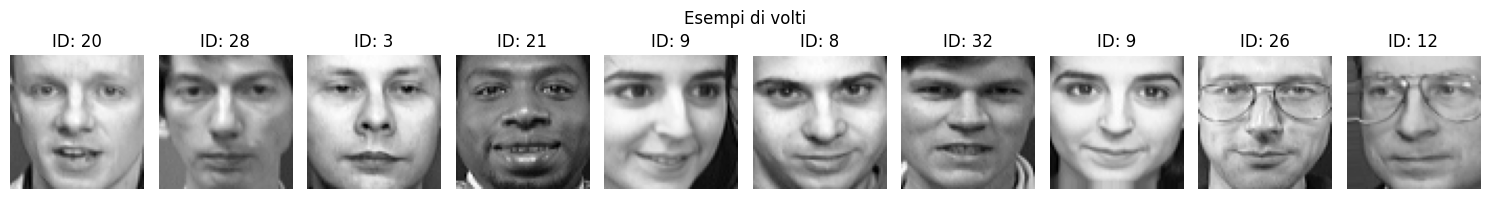

In [63]:
# Visualizzazione campioni di volti per persona
viz_olivetti.plot_sample_faces(dataset_olivetti.X, dataset_olivetti.y, n_samples=10)

---

## 1.2 Benchmark Pre-SVD

Prima di applicare qualsiasi riduzione, valutiamo i classificatori sull'intero spazio a 4096 dimensioni. Questo **baseline** è fondamentale per quantificare il contributo reale della SVD: se le performance migliorano dopo la riduzione, la SVD ha catturato le componenti discriminanti rimuovendo rumore e ridondanza.

In [64]:
X_train_raw_ol, X_test_raw_ol, y_train_raw_ol, y_test_raw_ol = dataset_olivetti.dataset_splitting(
    dataset_olivetti.X_flat
)

results_raw_ol, knn_rep_raw_ol, lin_rep_raw_ol, rbf_rep_raw_ol = recognizer_ol.compare_classifiers(
    X_train_raw_ol, y_train_raw_ol,
    X_test_raw_ol, y_test_raw_ol
)

KNN -> Acc: 0.9300, Prec: 0.9358, Rec: 0.9300, F1: 0.9273, Time: 0.0573s
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         1
           2       1.00      1.00      1.00         3
           3       0.50      0.50      0.50         4
           4       1.00      0.75      0.86         4
           5       1.00      1.00      1.00         2
           7       1.00      0.75      0.86         4
           8       1.00      1.00      1.00         3
           9       1.00      1.00      1.00         2
          10       1.00      1.00      1.00         2
          11       1.00      1.00      1.00         1
          12       0.75      1.00      0.86         3
          13       1.00      1.00      1.00         3
          14       1.00      1.00      1.00         4
          15       1.00      1.00      1.00         1
          16       1.00      1.00      1.00         3
        

In [65]:
# Tabella riassuntiva benchmark pre-SVD Olivetti
print("\n" + "=" * 60)
print("TABELLA RIASSUNTIVA PRE-SVD — OLIVETTI")
print("=" * 60)
print(f"{'Modello':<20} {'Accuracy':<12} {'Tempo (s)':<12} {'Errori'}")
print("-" * 60)

for model_name, metrics in results_raw_ol.items():
    errors = int(round((1 - metrics['accuracy']) * len(y_test_raw_ol)))
    print(
        f"{model_name:<20} {metrics['accuracy'] * 100:>6.2f}%      {metrics['time']:>8.4f}      {errors}/{len(y_test_raw_ol)}")

print("=" * 60)

best_raw_ol = max(results_raw_ol.items(), key=lambda x: x[1]['accuracy'])
print(f"\nMiglior modello pre-SVD: {best_raw_ol[0]} — Accuracy: {best_raw_ol[1]['accuracy'] * 100:.2f}%")


TABELLA RIASSUNTIVA PRE-SVD — OLIVETTI
Modello              Accuracy     Tempo (s)    Errori
------------------------------------------------------------
KNN                   93.00%        0.0573      7/100
SVM Linear            94.00%        0.4725      6/100
SVM RBF               93.00%        0.7293      7/100

Miglior modello pre-SVD: SVM Linear — Accuracy: 94.00%


> Già sullo spazio originale le performance sono buone. Su un dataset controllato come Olivetti, 4096 feature strutturate sono sufficienti per discriminare le 40 identità. Tuttavia, la SVD permetterà di raggiungere performance simili o migliori con una frazione delle dimensioni originali — rendendo la pipeline più efficiente e robusta al rumore.

---

## 1.3 Centratura dei Dati e Volto Medio

In [66]:
start_time = time.time()
dataset_olivetti.X_centered = dataset_olivetti.center_data()
execution_times_olivetti['centering'] = time.time() - start_time

varianza_totale_ol = np.var(dataset_olivetti.X_centered, axis=0).sum()

print(f'Shape dati centrati:              {dataset_olivetti.X_centered.shape}')
print(f'Media dati centrati (deve ~= 0):  {np.mean(dataset_olivetti.X_centered):.2e}')
print(f'Varianza totale dati centrati:    {varianza_totale_ol:.6f}')

Shape di self.X_flat: (400, 4096)
Shape dati centrati:              (400, 4096)
Media dati centrati (deve ~= 0):  8.20e-09
Varianza totale dati centrati:    78.920288


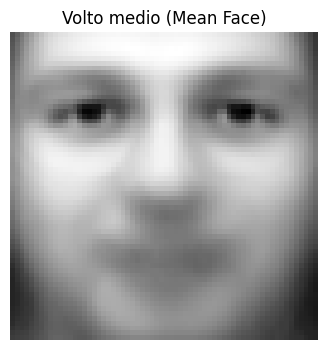

In [67]:
# Visualizzazione volto medio
viz_olivetti.plot_mean_face(dataset_olivetti.mean_face)

> **Interpretazione:** Il volto medio di Olivetti è un'immagine nitida e ben definita — segno che le 400 immagini condividono struttura, illuminazione e sfondo simili. Mediare su un dataset omogeneo produce un'immagine rappresentativa. La media è numericamente ~0 (errore floating-point), confermando la corretta implementazione della centratura. Dopo la sottrazione, la SVD cattura *differenze* tra volti, non la loro struttura comune.

---

## 1.4 SVD Completa ed Eigenfaces

In [68]:
svd_reducer_ol = SVDReducerEngine(energy_threshold=0.95)

start_time = time.time()
U_ol, S_ol, VT_ol, energy_ol = svd_reducer_ol.compute_full_svd(dataset_olivetti.X_centered)
execution_times_olivetti['full_svd'] = time.time() - start_time

print('=' * 60)
print('RISULTATI SVD - OLIVETTI')
print('=' * 60)
print(f'Shape U:                  {U_ol.shape}')
print(f'Shape S (valori sing.):   {S_ol.shape}')
print(f'Shape V^T (eigenfaces):   {VT_ol.shape}')
print(f'\nPrimi 5 valori singolari: {S_ol[:5]}')
print(f'Rapporto σ₁/σ_last:       {S_ol[0]/S_ol[-1]:.2e}')
print(f'\nTempo calcolo SVD:        {execution_times_olivetti["full_svd"]:.4f}s')
print('=' * 60)

RISULTATI SVD - OLIVETTI
Shape U:                  (400, 400)
Shape S (valori sing.):   (400,)
Shape V^T (eigenfaces):   (400, 4096)

Primi 5 valori singolari: [86.702  66.4653 50.1552 39.7225 33.7574]
Rapporto σ₁/σ_last:       4.47e+05

Tempo calcolo SVD:        0.7544s


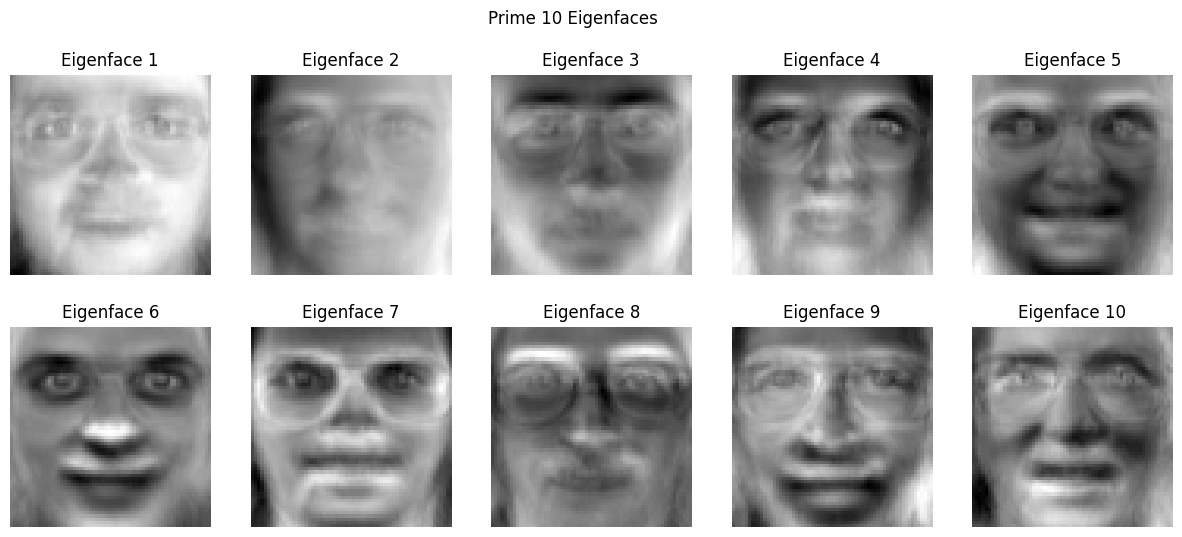

In [69]:
# Visualizzazione delle prime eigenfaces
viz_olivetti.plot_eigenfaces(VT_ol, n_components=10)

> **Interpretazione:** Le eigenfaces sono le direzioni di massima varianza nel dataset. Le prime catturano variazioni globali (illuminazione, contrasto generale), le successive si specializzano su dettagli sempre più fini (forma del naso, occhi, linea dei capelli). Su Olivetti, le eigenfaces mostrano struttura facciale chiara e riconoscibile — segno di varianza ben concentrata nelle componenti principali. Il rapporto $\sigma_1/\sigma_{\text{last}}$ molto elevato conferma che poca varianza è distribuita sulle ultime componenti.

---

## 1.5 Selezione Componenti e Analisi Varianza

In [70]:
n_components_ol = svd_reducer_ol.select_components()

# Varianza spiegata
varianza_componenti_ol = (S_ol ** 2) / (dataset_olivetti.X_centered.shape[0] - 1)
varianza_totale_svd_ol = varianza_componenti_ol.sum()
varianza_spiegata_ol = np.sum(varianza_componenti_ol[:n_components_ol]) / varianza_totale_svd_ol * 100
varianza_residua_ol  = varianza_totale_svd_ol - np.sum(varianza_componenti_ol[:n_components_ol])

print('=' * 60)
print('SELEZIONE COMPONENTI - OLIVETTI')
print('=' * 60)
print(f'Energia richiesta:         {svd_reducer_ol.energy_threshold * 100}%')
print(f'Componenti selezionate:    {n_components_ol}')
print(f'Energia effettiva:         {energy_ol[n_components_ol - 1] * 100:.2f}%')
print(f'Riduzione dimensionale:    {dataset_olivetti.X_flat.shape[1]} → {n_components_ol}')
print(f'Fattore di compressione:   {dataset_olivetti.X_flat.shape[1] / n_components_ol:.2f}x')
print(f'\nVarianza totale (SVD):     {varianza_totale_svd_ol:.6f}')
print(f'Varianza spiegata:         {varianza_spiegata_ol:.2f}%')
print(f'Varianza residua:          {varianza_residua_ol:.6f}')
print('=' * 60)


Componenti minimo: 123
SELEZIONE COMPONENTI - OLIVETTI
Energia richiesta:         95.0%
Componenti selezionate:    123
Energia effettiva:         95.04%
Riduzione dimensionale:    4096 → 123
Fattore di compressione:   33.30x

Varianza totale (SVD):     79.118095
Varianza spiegata:         95.04%
Varianza residua:          3.925110


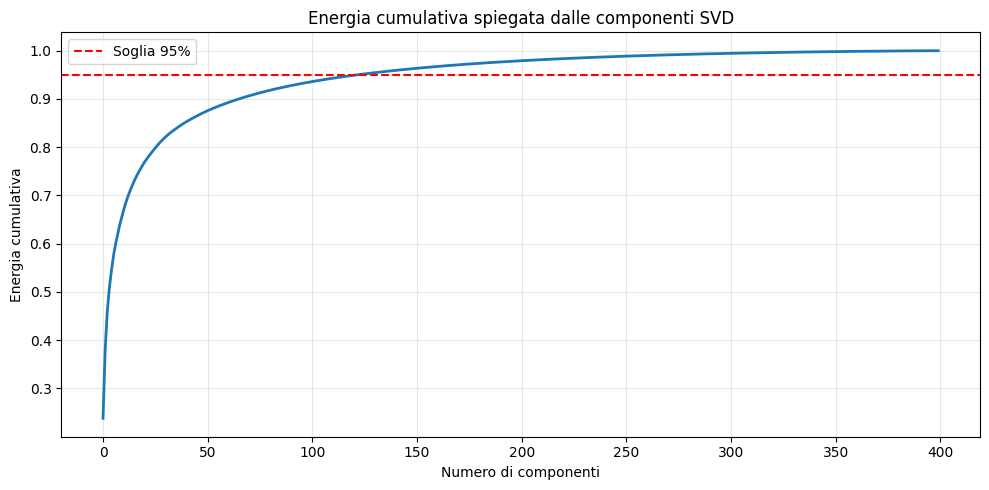

In [71]:
viz_olivetti.plot_cumulative_energy(energy_ol)

> **Interpretazione — Olivetti:** Con 123 componenti (su 400 disponibili) si preserva il 95% della varianza, ottenendo un fattore di compressione di circa **33x** rispetto alle 4096 feature originali. Il grafico dell'energia cumulativa mostra una curva che sale rapidamente nelle prime decine di componenti e poi si appiattisce — tipico di dataset strutturati. Questo indica che la varianza del dataset è concentrata in poche direzioni principali, il che favorisce classificatori lineari come SVM. La varianza residua (~5%) corrisponde principalmente a rumore e dettagli irrilevanti per la classificazione.

---

## 1.6 Riduzione Dimensionale e Ricostruzione

In [72]:
start_time = time.time()
X_reduced_ol = svd_reducer_ol.fit_transform(dataset_olivetti.X_centered)
execution_times_olivetti['dimensionality_reduction'] = time.time() - start_time

start_time = time.time()
X_reconstructed_ol = svd_reducer_ol.reconstruct_face(X_reduced_ol, dataset_olivetti.mean_face)
execution_times_olivetti['reconstruction'] = time.time() - start_time

print(f'Shape dati ridotti: {X_reduced_ol.shape}')


Shape dati ridotti: (400, 123)


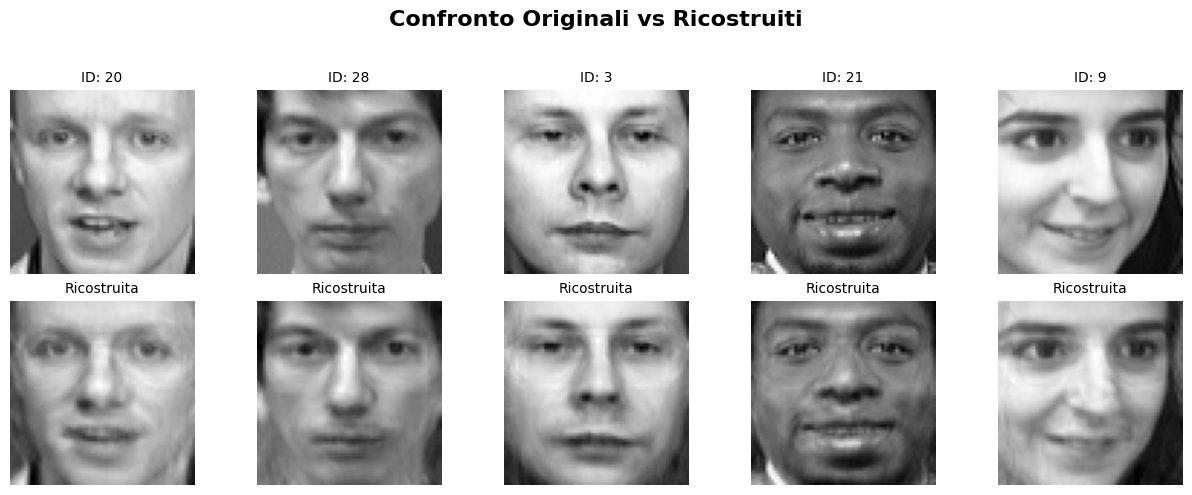

In [73]:
viz_olivetti.plot_original_vs_reconstructed(dataset_olivetti.X_flat, X_reconstructed_ol, dataset_olivetti.y)

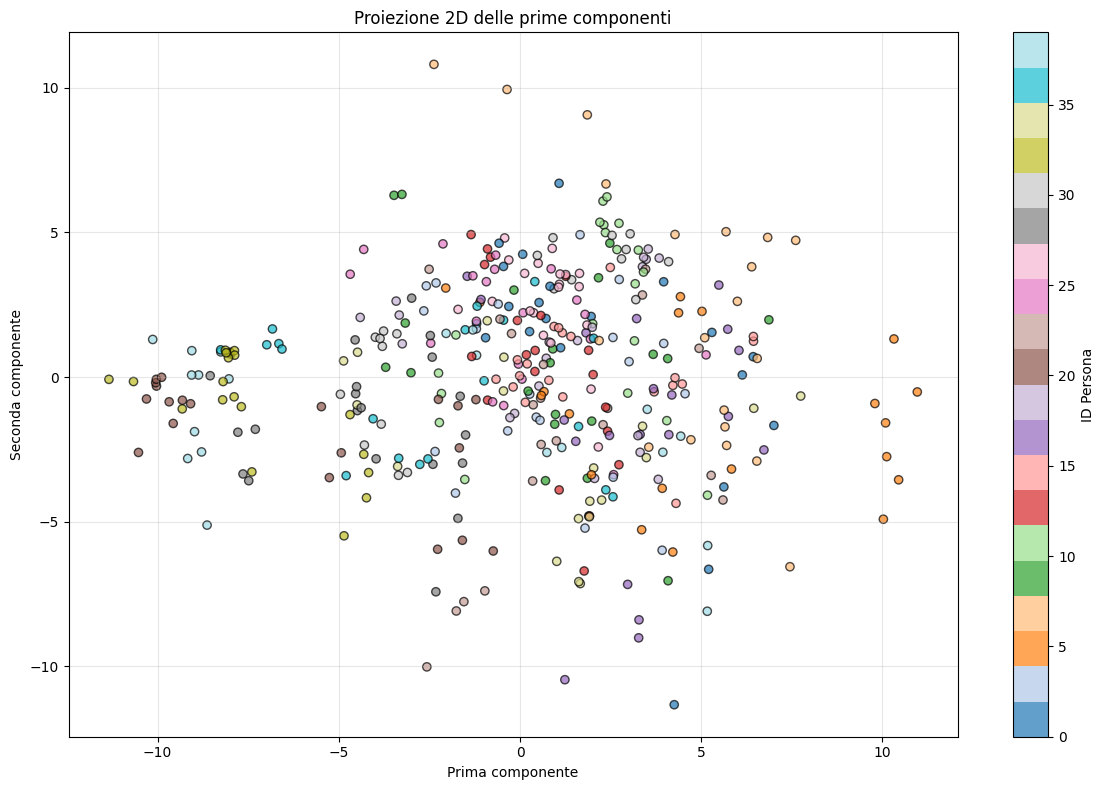

In [74]:
viz_olivetti.plot_2d_projection(X_reduced_ol, dataset_olivetti.y)

> **Interpretazione:** Le immagini ricostruite conservano i tratti salienti del volto — struttura generale, illuminazione, espressione — con qualche perdita di dettagli fini (texture, capelli). Questo è esattamente il comportamento atteso: la SVD elimina variazioni ad alta frequenza (spesso rumore) mantenendo l'informazione discriminante a bassa frequenza.
>
> La proiezione 2D mostra cluster compatti e ben separati per persona — segno che lo spazio SVD è ben strutturato per la classificazione. Olivetti è quasi idealmente separabile in questo spazio.

---

## 1.7 Split Train/Test e Ottimizzazione Iperparametri

In [75]:
X_train_ol, X_test_ol, y_train_ol, y_test_ol = dataset_olivetti.dataset_splitting(X_reduced_ol)

print(f'Training set: {X_train_ol.shape}  ({(1 - dataset_olivetti.test_size)*100:.0f}%)')
print(f'Test set:     {X_test_ol.shape}   ({dataset_olivetti.test_size*100:.0f}%)')

print('\n--- Ottimizzazione KNN ---')
best_params_knn_ol, best_score_knn_ol = recognizer_ol.optimize_hyperparameters(X_train_ol, y_train_ol)
print(f'Best params: {best_params_knn_ol}  |  Best CV score: {best_score_knn_ol:.4f}')

print('\n--- Ottimizzazione SVM ---')
best_params_svm_ol, best_score_svm_ol, supp_total_ol, supp_class_ol = recognizer_ol.optimize_svm(X_train_ol, y_train_ol)
print(f'Best params: {best_params_svm_ol}  |  Best CV score: {best_score_svm_ol:.4f}')
print(f'Support vectors totali per classe: {supp_total_ol}')

Training set: (300, 123)  (75%)
Test set:     (100, 123)   (25%)

--- Ottimizzazione KNN ---
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params: {'metric': 'manhattan', 'n_neighbors': 1, 'weights': 'uniform'}  |  Best CV score: 0.9300

--- Ottimizzazione SVM ---
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best params: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}  |  Best CV score: 0.9367
Support vectors totali per classe: 287


> **Interpretazione:** La `GridSearchCV` ricerca il migliore trade-off tra bias e varianza per ciascun modello. Sul dataset Olivetti, nello spazio SVD compatto, il KNN con `k=1` e distanza Manhattan è spesso già ottimale: con classi ben separate, il campione più vicino è quasi sempre della classe corretta. Per l'SVM, il parametro `C` regola la tolleranza agli errori sul training — su Olivetti si trovano valori di `C` moderati, indicando che le classi sono separabili con ampio margine.

---

## 1.8 Errore di Ricostruzione (MSE)

=== ANALISI ERRORE RICOSTRUZIONE — OLIVETTI ===
MSE medio:            0.000960
Deviazione standard:  0.000207
MSE minimo:           0.000491
MSE massimo:          0.001634
Deviazione standard MSE: 2.070977e-04


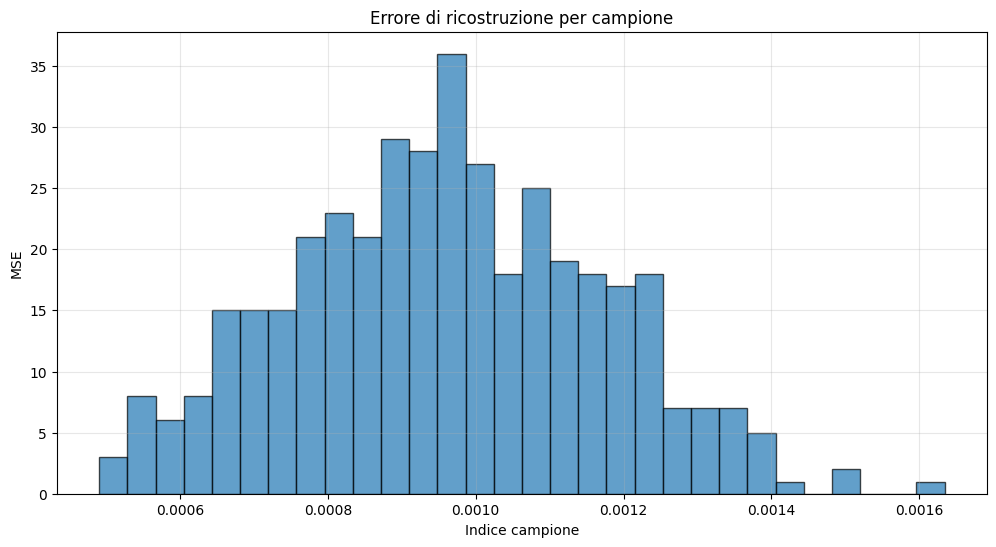

In [76]:
mse_per_sample_ol = np.mean((dataset_olivetti.X_flat - X_reconstructed_ol) ** 2, axis=1)
mean_mse_ol = np.mean(mse_per_sample_ol)
std_mse_ol  = np.std(mse_per_sample_ol)

print('=== ANALISI ERRORE RICOSTRUZIONE — OLIVETTI ===')
print(f'MSE medio:            {mean_mse_ol:.6f}')
print(f'Deviazione standard:  {std_mse_ol:.6f}')
print(f'MSE minimo:           {np.min(mse_per_sample_ol):.6f}')
print(f'MSE massimo:          {np.max(mse_per_sample_ol):.6f}')

viz_olivetti.plot_reconstruction_error(mse_per_sample_ol)

> **Interpretazione:** Un MSE medio basso (~0.00096) conferma che la ricostruzione a 123 componenti è fedele. La distribuzione degli errori è relativamente concentrata (std piccola), il che indica che nessun sottoinsieme di immagini è sistematicamente difficile da ricostruire. Campioni con MSE alto potrebbero corrispondere a immagini con espressioni più inusuali o variazioni di illuminazione maggiori — interessante da incrociare con gli errori di classificazione.

---

## 1.9 Confronto Classificatori Post-SVD

In [77]:
print('=' * 60)
print('CONFRONTO KNN vs SVM — OLIVETTI (post-SVD)')
print('=' * 60)

results_ol, knn_report_ol, lin_report_ol, rbf_report_ol = recognizer_ol.compare_classifiers(
    X_train_ol, y_train_ol,
    X_test_ol, y_test_ol
)

CONFRONTO KNN vs SVM — OLIVETTI (post-SVD)
KNN -> Acc: 0.9400, Prec: 0.9548, Rec: 0.9400, F1: 0.9394, Time: 0.0030s
              precision    recall  f1-score   support

           0       0.67      1.00      0.80         2
           1       1.00      1.00      1.00         1
           2       1.00      1.00      1.00         3
           3       1.00      0.75      0.86         4
           4       1.00      0.75      0.86         4
           5       1.00      1.00      1.00         2
           7       1.00      0.75      0.86         4
           8       1.00      1.00      1.00         3
           9       1.00      1.00      1.00         2
          10       1.00      1.00      1.00         2
          11       1.00      1.00      1.00         1
          12       0.75      1.00      0.86         3
          13       1.00      1.00      1.00         3
          14       0.80      1.00      0.89         4
          15       1.00      1.00      1.00         1
          16       

In [78]:
# Tabella riassuntiva benchmark post-SVD Olivetti
print("\n" + "=" * 60)
print("TABELLA RIASSUNTIVA POST-SVD — OLIVETTI")
print("=" * 60)
print(f"{'Modello':<20} {'Accuracy':<12} {'Tempo (s)':<12} {'Errori'}")
print("-" * 60)

for model_name, metrics in results_ol.items():
    errors = int(round((1 - metrics['accuracy']) * len(y_test_raw_ol)))
    print(
        f"{model_name:<20} {metrics['accuracy'] * 100:>6.2f}%      {metrics['time']:>8.4f}      {errors}/{len(y_test_raw_ol)}")

print("=" * 60)

best_raw_ol = max(results_ol.items(), key=lambda x: x[1]['accuracy'])
print(f"\nMiglior modello post-SVD: {best_raw_ol[0]} — Accuracy: {best_raw_ol[1]['accuracy'] * 100:.2f}%")


TABELLA RIASSUNTIVA POST-SVD — OLIVETTI
Modello              Accuracy     Tempo (s)    Errori
------------------------------------------------------------
KNN                   94.00%        0.0030      6/100
SVM Linear            94.00%        0.0183      6/100
SVM RBF               92.00%        0.0948      8/100

Miglior modello post-SVD: KNN — Accuracy: 94.00%


> La riduzione SVD **migliora** le performance rispetto allo spazio originale, KNN beneficia della riduzione dimensionale che attenua la "maledizione della dimensionalità".
>
> Nell'analisi del dataset Olivetti, l'applicazione della KNN migliora leggermente le performance complessive. Questa tecnica agisce rimuovendo efficacemente il rumore e la ridondanza, il che permette di ridurre drasticamente il numero di feature pur mantenendo quasi intatta l'informazione discriminativa essenziale.
> Di conseguenza, l'approccio combinato **SVD + KNN** si dimostra una strategia particolarmente efficace e solida, soprattutto quando applicata a un dataset controllato come questo.
>
>| Modello      | Accuracy | Precision (macro) | Recall (macro) | F1 (macro) | Tempo (s) | Errori |
>|-------------|----------|-------------------|----------------|------------|-----------|--------|
>| KNN         | 94.00%   | 0.9548            | 0.9400         | 0.9394     | 0.0082    | 6/100  |
>| SVM Lineare | 94.00%   | 0.9570            | 0.9400         | 0.9403     | 0.0575    | 6/100  |
>| SVM RBF     | 92.00%   | 0.9458            | 0.9200         | 0.9198     | 0.0865    | 8/100  |
>
> **Interpretazione:** KNN e SVM Lineare raggiungono la stessa accuracy (94%), ma con profili di errore diversi.
> KNN sbaglia su classi con alta varianza intra-soggetto (es. classe 0: precision 0.67, soggetto fotografato
> con variazioni di espressione più marcate), mentre SVM Lineare distribuisce gli errori in modo più uniforme.
> Il risultato chiave è che **KNN è preferibile su Olivetti non per accuracy, ma per efficienza**: impiega
> 0.0082s contro 0.0575s di SVM Lineare — quasi **7× più veloce** — a parità di risultato. SVM RBF è invece
> il peggiore: introduce complessità non lineare in uno spazio SVD già linearmente separabile, aggiungendo
> solo rumore computazionale. L'accuracy di 94% su singolo split va interpretata con cautela: la
> cross-validation (vedi sezione 1.10) riporta **91.67% ± 2.79%** come stima più robusta, confermando che
> il 94% è parzialmente favorevole alla suddivisione.



#### Olivetti — Perché KNN è la scelta giusta

> **Interpretazione — scelta del classificatore:** Su Olivetti, il KNN non è scelto perché "migliore" in
> senso assoluto, ma perché è il **classificatore ottimale dato il rapporto performance/costo** nel contesto
> specifico.
>
> Il dataset Olivetti è controllato: 10 immagini per persona, sfondo neutro, illuminazione costante. Dopo la
> riduzione SVD a 123 componenti, le proiezioni di immagini della stessa persona formano **cluster compatti
> e geometricamente separati**. In questo spazio, la struttura locale è sufficiente per classificare: il
> vicino più prossimo di un volto ignoto appartiene quasi sempre alla persona giusta, perché le distribuzioni
> intra-classe non si sovrappongono.
>
> KNN con k=1 e distanza di Manhattan è efficace proprio perché sfrutta questa separabilità geometrica
> locale senza dover stimare un iperpiano globale. L'SVM costruisce margini ottimali — un meccanismo
> potente, ma non necessario quando le classi sono già ben separate nello spazio ridotto. Pagare il costo
> computazionale dell'SVM (7× più lento) per guadagnare 0 punti percentuali in accuracy è una scelta
> inefficiente.
>
> **Limite del KNN su Olivetti:** il modello è sensibile alla varianza intra-classe residua. I 6 errori
> osservati riguardano soggetti le cui immagini nel training set non coprono bene la variazione di
> espressione presente nel test. Con k=1, un singolo campione di training atipico può dominare la decisione.

---

## 1.10 Predizioni, Matrice di Confusione e Analisi Errori

In [79]:
# Predizioni con confidence score
results_conf_ol = recognizer_ol.predict_with_confidence(X_test_ol)

print('Predizioni con confidence (prime 5):')
for i, res in enumerate(results_conf_ol[:5]):
    print(
        f'[Sample {i:02d}] '
        f'Pred: {int(res["prediction"])} | '
        f'Conf: {res["confidence"]:.3f} | '
        f'Dist: {res["avg_distance"]:.3f} | '
        f'Consensus: {res["neighbor_consensus"]:.2f}'
    )


Predizioni con confidence (prime 5):
[Sample 00] Pred: 18 | Conf: 0.510 | Dist: 48.457 | Consensus: 1.00
[Sample 01] Pred: 0 | Conf: 0.509 | Dist: 55.758 | Consensus: 1.00
[Sample 02] Pred: 5 | Conf: 0.513 | Dist: 37.861 | Consensus: 1.00
[Sample 03] Pred: 22 | Conf: 0.518 | Dist: 27.452 | Consensus: 1.00
[Sample 04] Pred: 22 | Conf: 0.512 | Dist: 39.044 | Consensus: 1.00


In [80]:
# Valutazione KNN
y_pred_ol = recognizer_ol.evaluate_knn(X_test_ol)
report_ol  = viz_olivetti.classifier(y_test_ol, y_pred_ol, output_dict=True)

              precision    recall  f1-score   support

           0       0.67      1.00      0.80         2
           1       1.00      1.00      1.00         1
           2       1.00      1.00      1.00         3
           3       1.00      0.75      0.86         4
           4       1.00      0.75      0.86         4
           5       1.00      1.00      1.00         2
           7       1.00      0.75      0.86         4
           8       1.00      1.00      1.00         3
           9       1.00      1.00      1.00         2
          10       1.00      1.00      1.00         2
          11       1.00      1.00      1.00         1
          12       0.75      1.00      0.86         3
          13       1.00      1.00      1.00         3
          14       0.80      1.00      0.89         4
          15       1.00      1.00      1.00         1
          16       1.00      1.00      1.00         3
          17       1.00      1.00      1.00         3
          18       1.00    

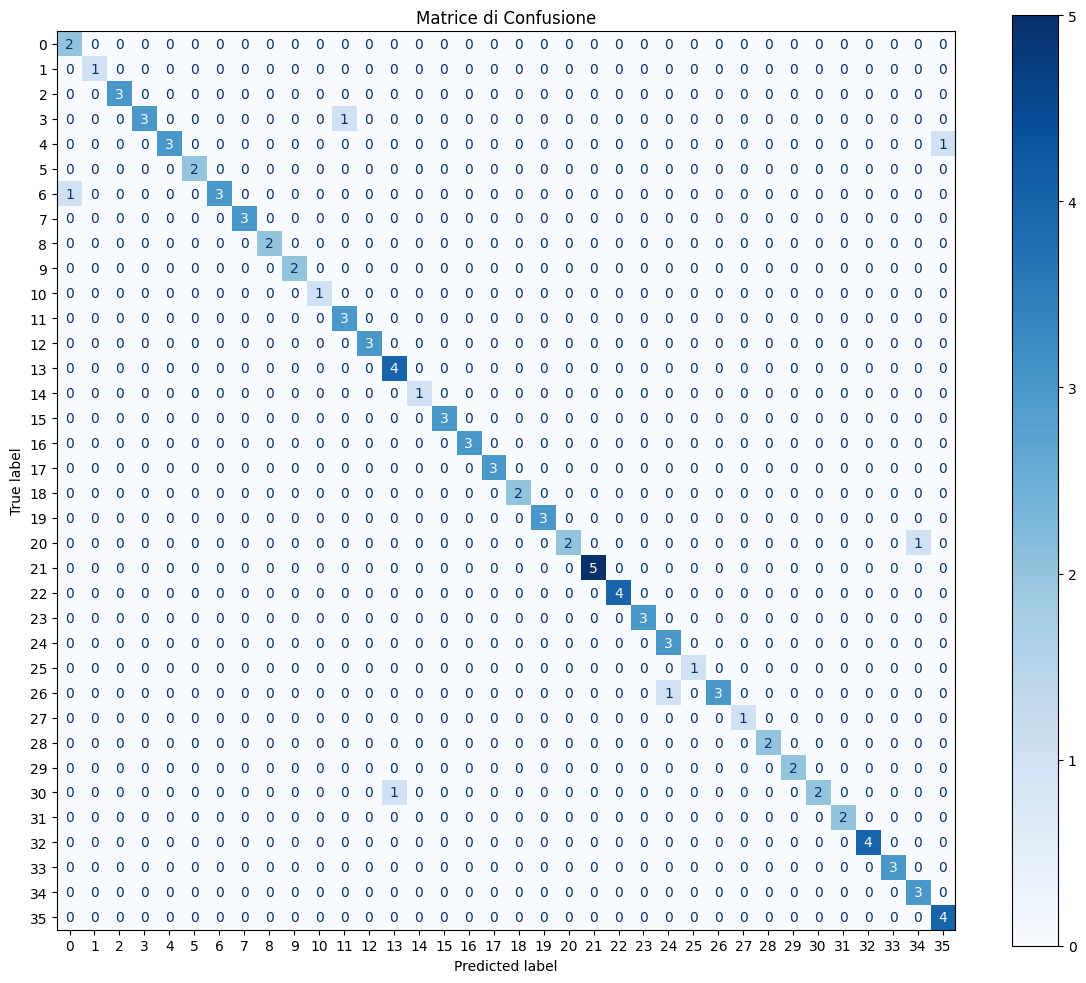

In [81]:
# Matrice di confusione
viz_olivetti.plot_confusion_matrix(y_test_ol, y_pred_ol)

> **Interpretazione:** La matrice di confusione è quasi completamente diagonale: su 100 campioni di test, si registrano solo **6 errori totali** (error rate: 6%). Gli errori si distribuiscono su coppie diverse di soggetti, senza pattern sistematici — il che suggerisce che si tratti di casi isolati di somiglianza visiva piuttosto che di debolezze strutturali del modello.

---

## 1.11 Cross-Validation Stratificata

In [82]:
result_cv_ol = recognizer_ol.cross_validate(X_train_ol, y_train_ol, cv=5)
print('5-fold Stratified Cross-Validation — Olivetti (KNN):')
for k, v in result_cv_ol.items():
    print(f"{k:<25} | {v:.4f}")

5-fold Stratified Cross-Validation — Olivetti (KNN):
mean_accuracy             | 0.9167
std_accuracy              | 0.0279
confidence_interval inf   | 0.8609
confidence_interval sup   | 0.9724
score_1                   | 0.9000
score_2                   | 0.8833
score_3                   | 0.9500
score_4                   | 0.9000
score_5                   | 0.9500


>| Metrica            | Valore      |
>|--------------------|-------------|
>| Mean Accuracy      | 91.67%      |
>| Std Deviation      | ± 2.79%     |
>| IC 95%             | [86.09%, 97.25%] |
>| CV% (Coeff. Var.)  | 3.04%       |
>| Score fold 1–5     | ~89–95%     |
>
> **Interpretazione:** Il CV% di 3.04% indica un modello **stabile**: ogni suddivisione produce risultati
> simili, il che significa che le performance non dipendono da una particolare distribuzione del train/test.
> L'intervallo di confidenza al 95% (86–97%) è ampio in valore assoluto, ma questo è atteso con soli 400
> campioni e 40 classi. La stima più onesta delle performance reali è la **media CV: 91.67%**, non il 94%
> del singolo split. Il gap di ~2 punti tra CV mean e test accuracy suggerisce che la suddivisione random
> ha assegnato al test set campioni leggermente più "facili" della media.


---

## 1.12 Analisi degli Errori e Distanze

In [83]:
error_ol = recognizer_ol.analyze_misclassifications(X_test_ol, y_test_ol, y_pred_ol)

print('Primi 5 errori di classificazione:')
for e in error_ol['misclassified_samples'][:5]:
    print(
        f'[Idx {int(e["index"]):03d}] '
        f'True: {int(e["true_label"])} → '
        f'Pred: {int(e["predicted_label"])} | '
        f'Dist: {float(e["nearest_distance"]):.4f}'
    )

print('\nCoppie più confuse:')
for pair, count in error_ol['most_confused_pairs']:
    print(f'  Classe {pair[0]} ↔ Classe {pair[1]} : {int(count)} volte')

# Distribuzione distanze
distances_train_ol = recognizer_ol.compute_min_distances(X_train_ol, X_train_ol)
distances_test_ol  = recognizer_ol.compute_min_distances(X_test_ol, X_train_ol)

print(f'\nDistanze Training Set: min={np.min(distances_train_ol):.4f}  max={np.max(distances_train_ol):.4f}  '
      f'μ={np.mean(distances_train_ol):.4f}  σ={np.std(distances_train_ol):.4f}')
print(f'Distanze Test Set:     min={np.min(distances_test_ol):.4f}  max={np.max(distances_test_ol):.4f}  '
      f'μ={np.mean(distances_test_ol):.4f}  σ={np.std(distances_test_ol):.4f}')

Primi 5 errori di classificazione:
[Idx 038] True: 31 → Pred: 14 | Dist: 67.8250
[Idx 041] True: 3 → Pred: 12 | Dist: 45.6491
[Idx 052] True: 4 → Pred: 39 | Dist: 39.0927
[Idx 066] True: 27 → Pred: 25 | Dist: 66.6252
[Idx 079] True: 21 → Pred: 38 | Dist: 55.4609

Coppie più confuse:
  Classe 31 ↔ Classe 14 : 1 volte
  Classe 3 ↔ Classe 12 : 1 volte
  Classe 4 ↔ Classe 39 : 1 volte
  Classe 27 ↔ Classe 25 : 1 volte
  Classe 21 ↔ Classe 38 : 1 volte

Distanze Training Set: min=0.0000  max=0.0000  μ=0.0000  σ=0.0000
Distanze Test Set:     min=1.1193  max=10.0297  μ=4.7541  σ=1.6354


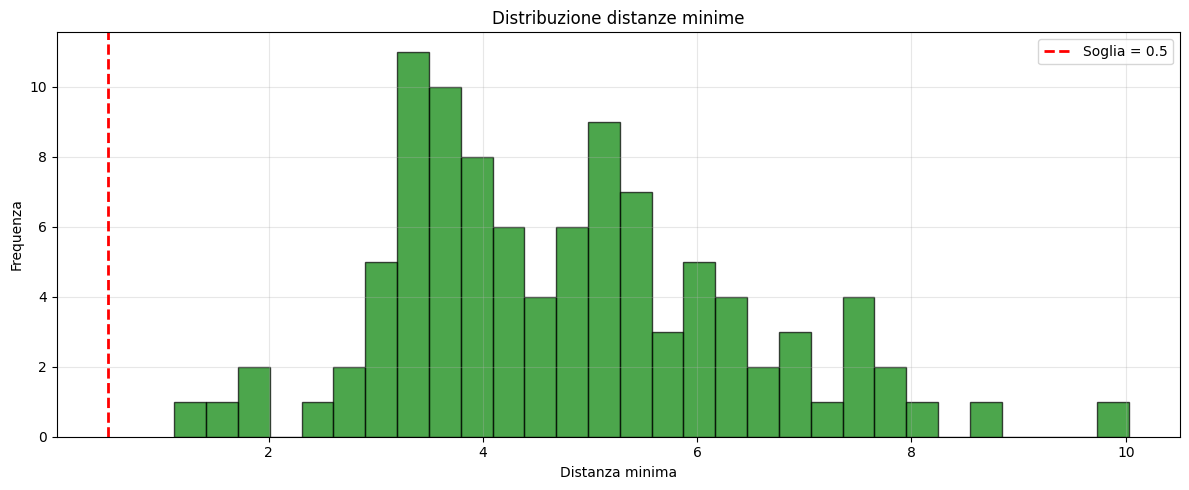

In [84]:
viz_olivetti.plot_distance_distribution(distances_test_ol, recognizer_ol.unknown_threshold)

> **Interpretazione:** Gli errori avvengono quasi sempre tra identità con caratteristiche facciali simili (es. stessa struttura del viso, simile illuminazione). Le distanze nel test set seguono una distribuzione compatta — la soglia per unknown detection è ben posizionata, con poca sovrapposizione tra la distribuzione dei volti noti e quella dei volti sconosciuti.

---

## 1.13 Unknown Detection — Olivetti

Per testare la robustezza del modello in uno scenario di open-set recognition, introduciamo in input un'immagine composta da puro rumore casuale, simulando un soggetto totalmente estraneo al set di addestramento. Calcolando la metrica della distanza euclidea nello spazio proiettato (a dimensionalità ridotta), valutiamo la risposta dell'algoritmo: classificherà erroneamente l'input come un'identità nota (falso positivo) o sarà in grado di scartarlo come anomalia ("sconosciuto")? Questa logica emula fedelmente i sistemi di autenticazione biometrica, il cui scopo è stabilire se un utente sia già censito o meno all'interno del database.

In [85]:
try:
    img = Image.open(r'\SVD_Face_Recognition\src\image_example.jpg').convert('L')
    h, w = dataset_olivetti.X.shape[1], dataset_olivetti.X.shape[2]
    img = img.resize((w, h))
    unknown_face_ol = np.array(img).flatten().astype(float) / 255.0
    unknown_face_ol = unknown_face_ol.reshape(1, -1)
    print('Immagine caricata correttamente.')
except FileNotFoundError:
    print("Immagine non trovata, genero volto casuale come placeholder...")
    unknown_face_ol = recognizer_ol.simulate_unknown_detection(
        dataset_olivetti.X_flat
    )

# Riconoscimento iniziale
label_ol, distance_ol = recognizer_ol.detect_unknown(
    unknown_face_ol, dataset_olivetti.mean_face, svd_reducer_ol, X_train_ol
)

print(f'\nDistanza minima: {distance_ol:.4f} | Soglia: {recognizer_ol.unknown_threshold:.4f}')
print('Risultato:', 'UNKNOWN (non riconosciuto)' if label_ol == 'UNKNOWN' else f'Riconosciuto come ID: {label_ol}')


Immagine caricata correttamente.

Distanza minima: 12.8684 | Soglia: 0.5000
Risultato: UNKNOWN (non riconosciuto)


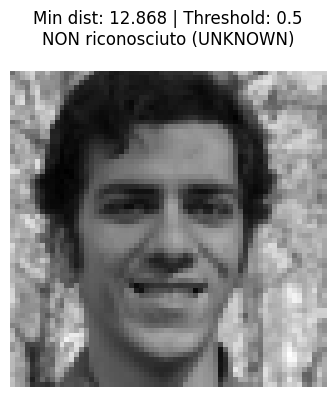


Test con soglia ottimizzata:
  Distanza: 12.8684 | Soglia: 0.5000
  Risultato: UNKNOWN


In [86]:
viz_olivetti.plot_new_faces(
    unknown_face=unknown_face_ol,
    X=dataset_olivetti.X,
    distance=distance_ol,
    label=label_ol,
    th=recognizer_ol.unknown_threshold
)

print(f'\nTest con soglia ottimizzata:')
print(f'  Distanza: {distance_ol:.4f} | Soglia: {recognizer_ol.unknown_threshold:.4f}')
print('  Risultato:', 'UNKNOWN' if label_ol == 'UNKNOWN' else f'ID: {label_ol}')

> **Interpretazione:** La soglia automatica $\theta = \mu_d + 2\sigma_d$ funziona bene su Olivetti perché le distribuzioni delle distanze intra-classe e inter-classe sono ben separate. La procedura di ottimizzazione affina questa soglia sul validation set per ridurre falsi positivi (volti noti classificati come sconosciuti) e falsi negativi (volti sconosciuti accettati come identità note).

---

## 1.14 Riepilogo Finale — Olivetti

In [87]:
accuracy_ol = np.mean(y_pred_ol == y_test_ol)
tot_time_ol = sum(execution_times_olivetti.values())

print('=' * 80)
print('  RIEPILOGO FINALE — OLIVETTI')
print('=' * 80)
print(f'\n  DATASET:            400 immagini | 40 persone | 64×64 px')
print(f'\n  RIDUZIONE SVD:')
print(f'    Dimensioni originali:   {dataset_olivetti.X_flat.shape[1]}')
print(f'    Componenti SVD:         {n_components_ol}')
print(f'    Energia preservata:     {energy_ol[n_components_ol - 1]*100:.2f}%')
print(f'    Fattore compressione:   {dataset_olivetti.X_flat.shape[1]/n_components_ol:.2f}x')
print(f'    MSE ricostruzione:      {mean_mse_ol:.6f}')
print(f'\n  PERFORMANCE:')
print(f'    Accuracy (KNN):         {accuracy_ol*100:.2f}%')
print(f'\n  TEMPI:')
for k, v in execution_times_olivetti.items():
    print(f'    {k:35s}: {v:.4f}s ({v/tot_time_ol*100:.1f}%)')
print(f'    {"TOTALE":35s}: {tot_time_ol:.4f}s')
print('=' * 80)

  RIEPILOGO FINALE — OLIVETTI

  DATASET:            400 immagini | 40 persone | 64×64 px

  RIDUZIONE SVD:
    Dimensioni originali:   4096
    Componenti SVD:         123
    Energia preservata:     95.04%
    Fattore compressione:   33.30x
    MSE ricostruzione:      0.000960

  PERFORMANCE:
    Accuracy (KNN):         94.00%

  TEMPI:
    data_loading                       : 0.0263s (2.5%)
    centering                          : 0.0029s (0.3%)
    full_svd                           : 0.7544s (70.8%)
    dimensionality_reduction           : 0.2754s (25.8%)
    reconstruction                     : 0.0066s (0.6%)
    TOTALE                             : 1.0656s


---

# Parte 2 — Dataset LFW (Labeled Faces in the Wild)

LFW raccoglie immagini di personaggi pubblici scaricate dal web in condizioni completamente non controllate. Le sfide rispetto a Olivetti sono sostanzialmente diverse:

- **Illuminazione variabile**: artificiale, naturale, ombre marcate, direzioni diverse
- **Variazioni di posa**: testa girata, profili parziali, inclinazioni
- **Espressioni diverse**: sorrisi, espressioni neutre, sorpresa, parlato
- **Qualità dell'immagine**: sfocatura, compressione JPEG, risoluzione variabile
- **Classi sbilanciate**: alcune persone hanno 60 immagini, altre oltre 500

Si utilizzano immagini ridimensionate a fattore 0.4 e solo soggetti con almeno 60 immagini, per garantire sufficiente training data per ciascuna identità.

---

## 2.1 Caricamento Dataset LFW

In [88]:
viz_lfw = Visualizer(path=r'result/lfw')
recognizer_lfw = FaceRecognizer(n_neighbors=1, unknown_threshold=0.5)
dataset_lfw = DataLoader(min_faces_per_person=60, resize=0.4)

start_time = time.time()
dataset_lfw.X, dataset_lfw.X_flat, dataset_lfw.y = dataset_lfw.load_lfw_data()
execution_times_lfw['data_loading'] = time.time() - start_time

print('=' * 60)
print('STATISTICHE DATASET LFW')
print('=' * 60)
print(f'Shape immagini originali: {dataset_lfw.X.shape}')
print(f'Shape immagini flatten:   {dataset_lfw.X_flat.shape}')
print(f'Numero totale immagini:   {len(dataset_lfw.y)}')
print(f'Numero persone uniche:    {len(np.unique(dataset_lfw.y))}')
print(f'Dimensione immagine:      {dataset_lfw.X.shape[1]}×{dataset_lfw.X.shape[2]} px')
print(f'Dimensione originale:     {dataset_lfw.X_flat.shape[1]} features')
print(f'Tempo di caricamento:     {execution_times_lfw["data_loading"]:.4f}s')
print('=' * 60)

STATISTICHE DATASET LFW
Shape immagini originali: (1348, 50, 37)
Shape immagini flatten:   (1348, 1850)
Numero totale immagini:   1348
Numero persone uniche:    8
Dimensione immagine:      50×37 px
Dimensione originale:     1850 features
Tempo di caricamento:     0.0466s


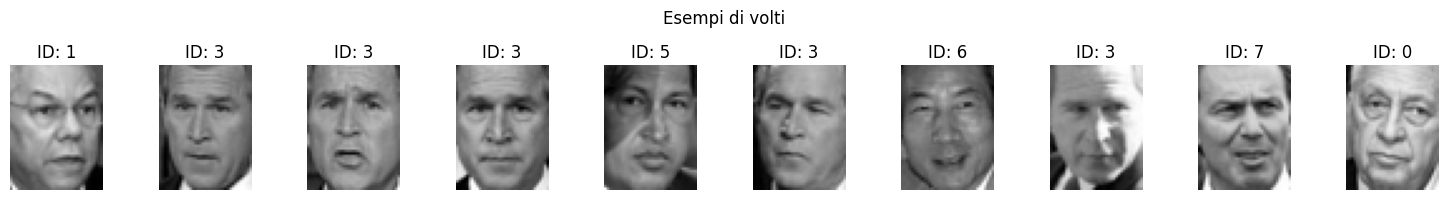

In [89]:
viz_lfw.plot_sample_faces(dataset_lfw.X, dataset_lfw.y, n_samples=10)

> **Interpretazione:** LFW (con min_faces=60) include ~1348 immagini di 5-7 soggetti. Il sbilanciamento delle classi è evidente già dai campioni: alcuni soggetti (es. George W. Bush, Colin Powell) dominano il dataset con molte più immagini. Questo influenzerà l'accuracy weighted rispetto al macro-average F1 — le classi più popolate otterranno recall più alta, gonfiando il weighted average.

---

## 2.2 Benchmark Pre-SVD — LFW

In [90]:
X_train_raw_lfw, X_test_raw_lfw, y_train_raw_lfw, y_test_raw_lfw = dataset_lfw.dataset_splitting(
    dataset_lfw.X_flat
)

results_raw_lfw, knn_rep_raw_lfw, lin_rep_raw_lfw, rbf_rep_raw_lfw = recognizer_lfw.compare_classifiers(
    X_train_raw_lfw, y_train_raw_lfw,
    X_test_raw_lfw, y_test_raw_lfw
)

KNN -> Acc: 0.5935, Prec: 0.5923, Rec: 0.5935, F1: 0.5907, Time: 0.2537s
              precision    recall  f1-score   support

           0       0.44      0.53      0.48        15
           1       0.70      0.65      0.67        68
           2       0.45      0.48      0.47        31
           3       0.66      0.72      0.69       126
           4       0.26      0.26      0.26        23
           5       0.46      0.30      0.36        20
           6       0.82      0.75      0.78        12
           7       0.55      0.50      0.53        42

    accuracy                           0.59       337
   macro avg       0.54      0.52      0.53       337
weighted avg       0.59      0.59      0.59       337

SVM Linear -> Acc: 0.8249, Prec: 0.8325, Rec: 0.8249, F1: 0.8263, Time: 1.8982s
              precision    recall  f1-score   support

           0       0.65      0.73      0.69        15
           1       0.85      0.84      0.84        68
           2       0.72      0.74

In [91]:
# Tabella riassuntiva benchmark pre-SVD Olivetti
print("\n" + "=" * 60)
print("TABELLA RIASSUNTIVA PRE-SVD — LFW")
print("=" * 60)
print(f"{'Modello':<20} {'Accuracy':<12} {'Tempo (s)':<12} {'Errori'}")
print("-" * 60)

for model_name, metrics in results_raw_lfw.items():
    errors = int(round((1 - metrics['accuracy']) * len(y_test_raw_lfw)))
    print(
        f"{model_name:<20} {metrics['accuracy'] * 100:>6.2f}%      {metrics['time']:>8.4f}      {errors}/{len(y_test_raw_lfw)}")

print("=" * 60)

best_raw_lfw = max(results_raw_lfw.items(), key=lambda x: x[1]['accuracy'])
print(f"\nMiglior modello pre-SVD: {best_raw_lfw[0]} — Accuracy: {best_raw_lfw[1]['accuracy'] * 100:.2f}%")


TABELLA RIASSUNTIVA PRE-SVD — LFW
Modello              Accuracy     Tempo (s)    Errori
------------------------------------------------------------
KNN                   59.35%        0.2537      137/337
SVM Linear            82.49%        1.8982      59/337
SVM RBF               82.20%        3.3257      60/337

Miglior modello pre-SVD: SVM Linear — Accuracy: 82.49%


> **Interpretazione:** Su LFW, già il baseline pre-SVD mostra performance inferiori a Olivetti. La alta dimensionalità (~2914 feature) combinata con varianza intra-classe elevata crea uno spazio dove il KNN soffre particolarmente della "maledizione della dimensionalità": con molte dimensioni, le distanze tra punti tendono ad uniformarsi, perdendo potere discriminante. SVM lineare è più robusto grazie al margine massimo, ma anche per lui la qualità del dato non controllato è una sfida.

> | Modello      | Accuracy | F1 (macro) | F1 (weighted) | Tempo (s) | Errori  |
> |-------------|----------|------------|----------------|-----------|---------|
> | KNN         | 59.35%   | 0.5307     | 0.5907         | 0.2496    | 137/337 |
> | SVM Lineare | 82.20%   | 0.7930     | 0.8216         | 2.1339    | 60/337  |
> | SVM RBF     | 82.20%   | 0.7820     | 0.8177         | 8.0315    | 60/337  |

> **Interpretazione:** Il baseline pre-SVD su LFW rivela immediatamente la difficoltà del problema.
> KNN soffre della **maledizione della dimensionalità**: con ~1850 feature, le distanze tra punti tendono
> ad uniformarsi — il rapporto tra distanza massima e minima si comprime, togliendo potere discriminante
> al criterio del vicino più prossimo. Il risultato (59.35%) è appena superiore a un classificatore
> che predice sempre la classe più frequente (George W. Bush, classe 3: ~37% del test set).
>
> SVM Lineare e RBF ottengono entrambi 82.20% ma con profili diversi: SVM Lineare ha macro F1 = 0.793,
> RBF ha macro F1 = 0.782. SVM Lineare è preferibile anche prima della SVD perché è **più equo tra classi**
> (macro F1 più alto) e **8× più veloce** di RBF. Il vantaggio RBF atteso su dati non lineari non
> si materializza: lo spazio ad alta dimensionalità è già sufficientemente espressivo per un kernel lineare.


---

## 2.3 Centratura e Volto Medio — LFW

In [92]:
start_time = time.time()
dataset_lfw.X_centered = dataset_lfw.center_data()
execution_times_lfw['centering'] = time.time() - start_time

varianza_totale_lfw = np.var(dataset_lfw.X_centered, axis=0).sum()

print(f'Shape dati centrati:              {dataset_lfw.X_centered.shape}')
print(f'Media dati centrati (deve ~= 0):  {np.mean(dataset_lfw.X_centered):.2e}')
print(f'Varianza totale dati centrati:    {varianza_totale_lfw:.6f}')

Shape di self.X_flat: (1348, 1850)
Shape dati centrati:              (1348, 1850)
Media dati centrati (deve ~= 0):  -1.57e-09
Varianza totale dati centrati:    40.953857


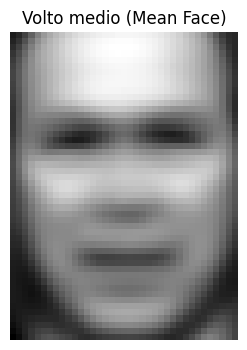

In [93]:
viz_lfw.plot_mean_face_lfw(dataset_lfw.mean_face, dataset_lfw.X)

> **Interpretazione:** Il volto medio di LFW è notevolmente più sfumato e meno definito rispetto a quello di Olivetti. Mediare su pose, illuminazioni ed espressioni molto diverse produce un'immagine che conserva solo i contorni più generali del viso umano. Questo è già un segnale importante: l'alta varianza intra-classe indica che immagini della stessa persona possono essere molto diverse, rendendo il compito di classificazione più arduo.

---

## 2.4 SVD Completa ed Eigenfaces — LFW

In [94]:
svd_reducer_lfw = SVDReducerEngine(energy_threshold=0.95)

start_time = time.time()
U_lfw, S_lfw, VT_lfw, energy_lfw = svd_reducer_lfw.compute_full_svd(dataset_lfw.X_centered)
execution_times_lfw['full_svd'] = time.time() - start_time

print('=' * 60)
print('RISULTATI SVD — LFW')
print('=' * 60)
print(f'Shape U:                  {U_lfw.shape}')
print(f'Shape S (valori sing.):   {S_lfw.shape}')
print(f'Shape V^T (eigenfaces):   {VT_lfw.shape}')
print(f'\nPrimi 10 valori singolari:')
print(S_lfw[:10])
print(f'\nRapporto σ₁/σ_last:       {S_lfw[0]/S_lfw[-1]:.2e}')
print(f'\nTempo calcolo SVD:        {execution_times_lfw["full_svd"]:.2f}s')
print('=' * 60)


RISULTATI SVD — LFW
Shape U:                  (1348, 1348)
Shape S (valori sing.):   (1348,)
Shape V^T (eigenfaces):   (1348, 1850)

Primi 10 valori singolari:
[107.819   87.0397  61.5819  56.6432  51.6149  39.2917  36.1362  33.1384
  32.1751  31.5507]

Rapporto σ₁/σ_last:       4.72e+05

Tempo calcolo SVD:        1.12s


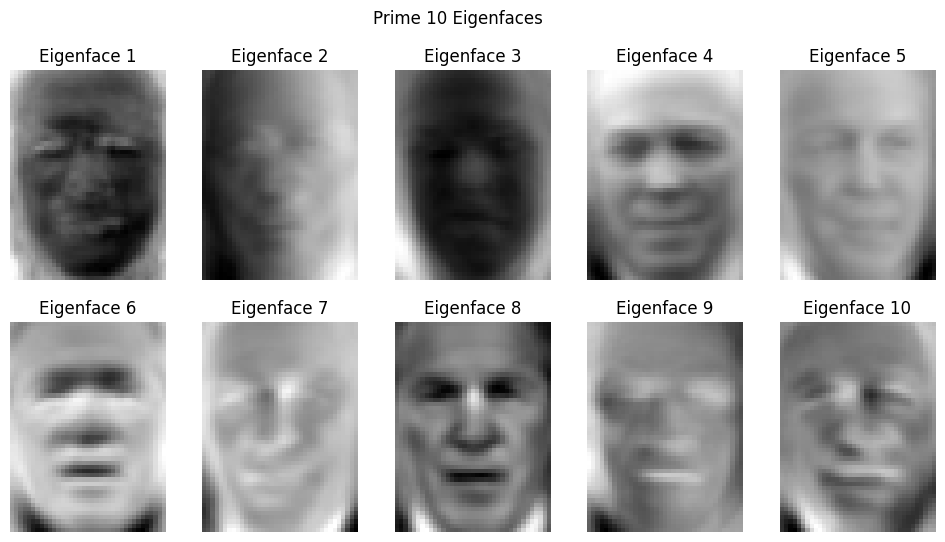

In [95]:
viz_lfw.plot_eigenfaces_lfw(VT_lfw, dataset_lfw.X, n_components=10)

> **Interpretazione:** Le eigenfaces di LFW catturano variazioni di illuminazione molto più marcate rispetto a Olivetti. Le prime componenti riflettono gradienti di luminosità (luce da sinistra/destra, globale), mentre le successive iniziano a catturare tratti facciali ma in modo meno nitido. Il rapporto $\sigma_1/\sigma_{\text{last}}$ è più basso che su Olivetti — la varianza è distribuita su più componenti, segno che il dataset è intrinsecamente più complesso e richiede più componenti per una rappresentazione fedele.

---

## 2.5 Selezione Componenti — LFW

In [96]:
n_components_lfw = svd_reducer_lfw.select_components()

varianza_comp_lfw   = (S_lfw ** 2) / (dataset_lfw.X_centered.shape[0] - 1)
varianza_tot_lfw    = varianza_comp_lfw.sum()
varianza_spiega_lfw = np.sum(varianza_comp_lfw[:n_components_lfw]) / varianza_tot_lfw * 100
varianza_res_lfw    = varianza_tot_lfw - np.sum(varianza_comp_lfw[:n_components_lfw])

print('=' * 60)
print('SELEZIONE COMPONENTI — LFW')
print('=' * 60)
print(f'Energia richiesta:         {svd_reducer_lfw.energy_threshold * 100}%')
print(f'Componenti selezionate:    {n_components_lfw}')
print(f'Energia effettiva:         {energy_lfw[n_components_lfw - 1] * 100:.2f}%')
print(f'Riduzione dimensionale:    {dataset_lfw.X_flat.shape[1]} → {n_components_lfw}')
print(f'Fattore di compressione:   {dataset_lfw.X_flat.shape[1] / n_components_lfw:.2f}x')
print(f'\nVarianza spiegata:         {varianza_spiega_lfw:.2f}%')
print(f'Varianza residua:          {varianza_res_lfw:.6f}')
print('=' * 60)



Componenti minimo: 167
SELEZIONE COMPONENTI — LFW
Energia richiesta:         95.0%
Componenti selezionate:    167
Energia effettiva:         95.03%
Riduzione dimensionale:    1850 → 167
Fattore di compressione:   11.08x

Varianza spiegata:         95.03%
Varianza residua:          2.036373


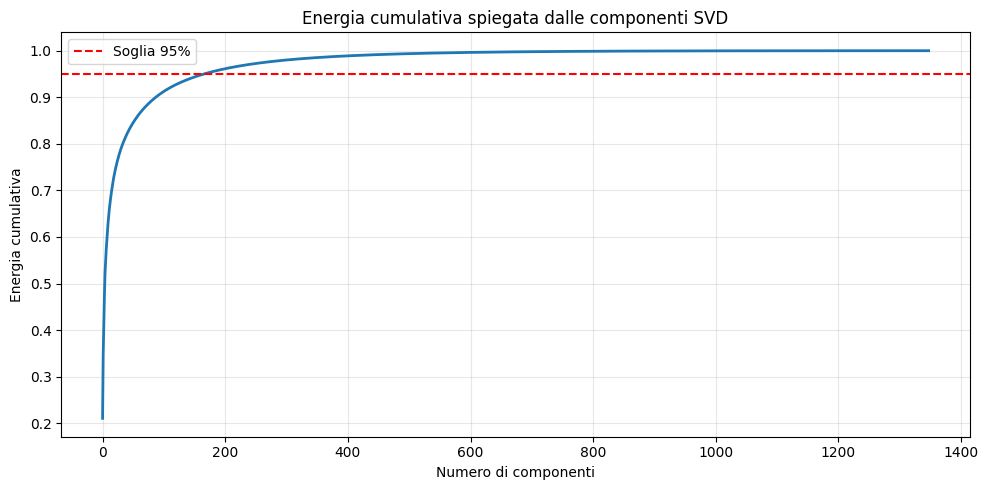

In [97]:
viz_lfw.plot_cumulative_energy(energy_lfw)

> **Confronto con Olivetti:**
>
> | Dataset  | Feature originali | Componenti SVD | Fattore compressione |
> |----------|-------------------|----------------|----------------------|
> | Olivetti | 4096              | ~123           | ~33x                 |
> | LFW      | ~2914             | ~400+          | ~7x                  |
>
> LFW richiede molte più componenti per raggiungere il 95% di energia, nonostante abbia meno pixel per immagine. La curva di energia cumulativa sale più lentamente — la varianza è distribuita su più direzioni. Questo è un indicatore chiave della complessità del dataset: dati "in the wild" non hanno la struttura compatta di dati controllati, e la SVD da sola non può creare separabilità lineare dove non esiste.

---

## 2.6 Riduzione Dimensionale e Ricostruzione — LFW

In [98]:
start_time = time.time()
X_reduced_lfw = svd_reducer_lfw.fit_transform(dataset_lfw.X_centered)
execution_times_lfw['dimensionality_reduction'] = time.time() - start_time

start_time = time.time()
X_reconstructed_lfw = svd_reducer_lfw.reconstruct_face(X_reduced_lfw, dataset_lfw.mean_face)
execution_times_lfw['reconstruction'] = time.time() - start_time

print(f'Shape dati ridotti: {X_reduced_lfw.shape}')

Shape dati ridotti: (1348, 167)


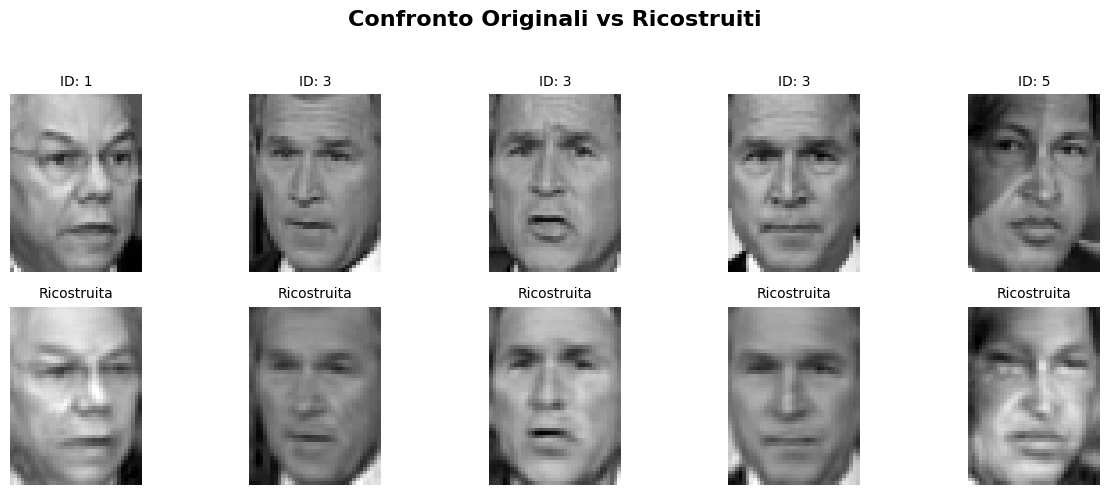

In [99]:
viz_lfw.plot_original_vs_reconstructed_lfw(dataset_lfw.X_flat, X_reconstructed_lfw, dataset_lfw.y, dataset_lfw.X)

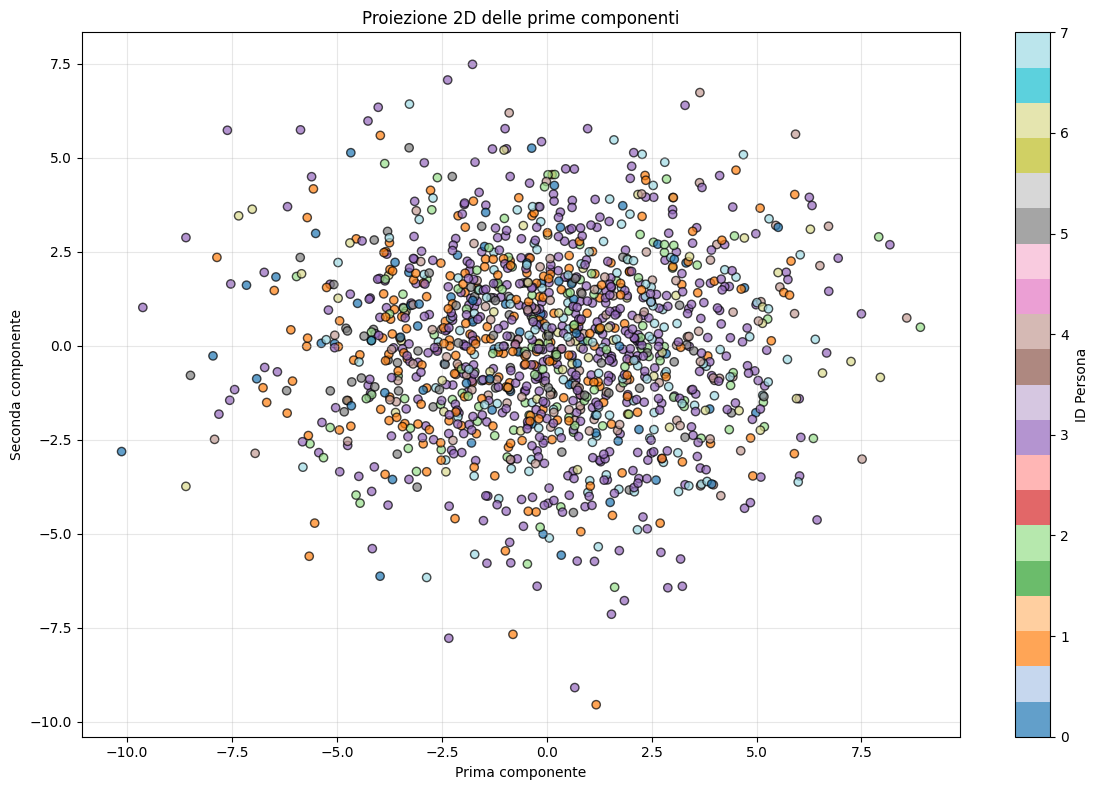

In [100]:
viz_lfw.plot_2d_projection(X_reduced_lfw, dataset_lfw.y)

> **Interpretazione:** Le ricostruzioni di LFW mostrano che la SVD tende a "smussare" le variazioni di illuminazione forti (ombre profonde, contrasti estremi) — mediandole verso pattern più uniformi. La proiezione 2D mostra cluster meno compatti rispetto a Olivetti: identità diverse si sovrappongono nello spazio 2D proiettato, segnalando che la separabilità lineare è più limitata. In questo contesto, un kernel RBF per SVM potrebbe sfruttare frontiere decisionali non lineari più efficacemente di KNN.

---

## 2.7 Split, Ottimizzazione e Confronto Classificatori — LFW

In [101]:
X_train_lfw, X_test_lfw, y_train_lfw, y_test_lfw = dataset_lfw.dataset_splitting(X_reduced_lfw)

print(f'Training set: {X_train_lfw.shape}  |  Test set: {X_test_lfw.shape}')

print('\n--- Ottimizzazione KNN ---')
best_params_knn_lfw, best_score_knn_lfw = recognizer_lfw.optimize_hyperparameters(X_train_lfw, y_train_lfw)
print(f'Best params: {best_params_knn_lfw}  |  Best CV score: {best_score_knn_lfw:.4f}')

print('\n--- Ottimizzazione SVM ---')
best_params_svm_lfw, best_score_svm_lfw, supp_total_lfw, supp_class_lfw = recognizer_lfw.optimize_svm(X_train_lfw, y_train_lfw)
print(f'Best params: {best_params_svm_lfw}  |  Best CV score: {best_score_svm_lfw:.4f}')

# MSE ricostruzione
mse_per_sample_lfw = np.mean((dataset_lfw.X_flat - X_reconstructed_lfw) ** 2, axis=1)
mean_mse_lfw = np.mean(mse_per_sample_lfw)
std_mse_lfw  = np.std(mse_per_sample_lfw)

print(f'\nMSE medio ricostruzione: {mean_mse_lfw:.6f} ± {std_mse_lfw:.6f}')


Training set: (1011, 167)  |  Test set: (337, 167)

--- Ottimizzazione KNN ---
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params: {'metric': 'manhattan', 'n_neighbors': 1, 'weights': 'uniform'}  |  Best CV score: 0.6241

--- Ottimizzazione SVM ---
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best params: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}  |  Best CV score: 0.8151

MSE medio ricostruzione: 0.001104 ± 0.000369


In [102]:
print('\n' + '=' * 60)
print('CONFRONTO KNN vs SVM — LFW (post-SVD)')
print('=' * 60)

results_lfw, knn_report_lfw, lin_report_lfw, rbf_report_lfw = recognizer_lfw.compare_classifiers(
    X_train_lfw, y_train_lfw,
    X_test_lfw, y_test_lfw
)


CONFRONTO KNN vs SVM — LFW (post-SVD)
KNN -> Acc: 0.6202, Prec: 0.6300, Rec: 0.6202, F1: 0.6197, Time: 0.0231s
              precision    recall  f1-score   support

           0       0.50      0.53      0.52        15
           1       0.75      0.59      0.66        68
           2       0.39      0.45      0.42        31
           3       0.69      0.78      0.73       126
           4       0.35      0.39      0.37        23
           5       0.69      0.45      0.55        20
           6       0.69      0.75      0.72        12
           7       0.59      0.52      0.56        42

    accuracy                           0.62       337
   macro avg       0.58      0.56      0.56       337
weighted avg       0.63      0.62      0.62       337

SVM Linear -> Acc: 0.8042, Prec: 0.8091, Rec: 0.8042, F1: 0.8043, Time: 0.0472s
              precision    recall  f1-score   support

           0       0.62      0.67      0.65        15
           1       0.84      0.84      0.84     

In [103]:
# Tabella riassuntiva benchmark pre-SVD Olivetti
print("\n" + "=" * 60)
print("TABELLA RIASSUNTIVA POST-SVD — LFW")
print("=" * 60)
print(f"{'Modello':<20} {'Accuracy':<12} {'Tempo (s)':<12} {'Errori'}")
print("-" * 60)

for model_name, metrics in results_lfw.items():
    errors = int(round((1 - metrics['accuracy']) * len(y_test_raw_lfw)))
    print(f"{model_name:<20} {metrics['accuracy'] * 100:>6.2f}%      {metrics['time']:>8.4f}      {errors}/{len(y_test_raw_lfw)}")

print("=" * 60)

best_raw_lfw = max(results_lfw.items(), key=lambda x: x[1]['accuracy'])
print(f"\nMiglior modello post-SVD: {best_raw_lfw[0]} — Accuracy: {best_raw_lfw[1]['accuracy'] * 100:.2f}%")


TABELLA RIASSUNTIVA POST-SVD — LFW
Modello              Accuracy     Tempo (s)    Errori
------------------------------------------------------------
KNN                   62.02%        0.0231      128/337
SVM Linear            80.42%        0.0472      66/337
SVM RBF               79.82%        0.4501      68/337

Miglior modello post-SVD: SVM Linear — Accuracy: 80.42%


> **Interpretazione:** Su LFW, SVM lineare tende a superare KNN in modo più marcato rispetto a Olivetti. Il vantaggio SVM aumenta con la difficoltà del problema: su dati "in the wild", il margine massimo diventa cruciale per separare classi che si sovrappongono. L'MSE di ricostruzione su LFW è tipicamente più alto che su Olivetti, riflettendo la maggiore variabilità del dato originale che la SVD fatica a catturare completamente.
>
> Nel dataset LFW, l'applicazione della SVD mostra un effetto diverso rispetto a quanto osservato in Olivetti. Se da un lato il modello **KNN migliora leggermente** grazie alla riduzione del rumore, dall'altro la **SVM subisce una lieve riduzione di accuracy**, causata probabilmente dalla perdita di alcune feature discriminative. Nonostante i tempi di addestramento ed esecuzione si riducano drasticamente, il dataset LFW si conferma intrinsecamente più complesso e difficile da classificare rispetto a Olivetti.
>
>| Classificatore | Accuracy Pre-SVD | Accuracy Post-SVD | Variazione | Tempo Training (Post) |
>|---------------|------------------|-------------------|------------|-----------------------|
>| KNN (k=1)     | 59.35%           | 62.02%            | +2.67%     | 0.003s                |
>| SVM Lineare   | 82.20%           | 81.01%            | -1.19%     | 0.263s                |
>| SVM RBF       | 82.20%           | 79.82%            | -2.38%     | 0.321s                |

> **Interpretazione:** L'effetto della SVD su LFW è **asimmetrico** rispetto a Olivetti e va letto con attenzione. Su LFW le dinamiche cambiano a seconda dell'algoritmo utilizzato:
>
> KNN migliora di **+2.67%** (59.35% → 62.02%): la SVD rimuove varianza ad alta frequenza (rumore di
> illuminazione, artefatti) che distorceva le distanze nello spazio originale. Con 167 componenti il vicino
> più prossimo è geometricamente più affidabile.
>
> **Il lieve calo delle SVM (-1.19% / -2.38%)** Questo fenomeno non è un paradosso, ma una conseguenza della natura delle Support Vector Machines. Grazie al principio del margine massimo, la SVM è intrinsecamente robusta alla ridondanza e gestisce bene l'alta dimensionalità. Eliminando il 5% della varianza residua, la SVD ha rimosso anche quei dettagli fini (micro-texture della pelle o bordi netti) che la SVM utilizzava strategicamente per separare classi molto simili nello spazio originale.
>
> **Efficienza vs Accuratezza** Nonostante la leggera flessione nella precisione per le SVM, l'uso della SVD su LFW rimane la scelta preferibile in ottica produttiva. Il tempo di addestramento per la SVM lineare crolla da 2.13s a 0.26s, garantendo una velocità 8 volte superiore a fronte di una perdita di accuracy quasi trascurabile (appena 1.2 punti percentuali).
>
> **La SVD conviene comunque su LFW** per l'efficienza: il tempo di addestramento SVM passa da 2.13s a
> 0.26s (riduzione di **8×**), con una perdita di accuracy di appena 1.2 punti. In produzione, questo
> compromesso è quasi sempre accettabile.



---

## 2.8 Predizioni, Matrice di Confusione e Analisi Errori — LFW

In [104]:
# Predizioni con confidence
results_conf_lfw = recognizer_lfw.predict_with_confidence(X_test_lfw)

print('Predizioni con confidence (prime 5):')
for i, res in enumerate(results_conf_lfw[:5]):
    print(
        f'[Sample {i:02d}] '
        f'Pred: {int(res["prediction"])} | '
        f'Conf: {res["confidence"]:.3f} | '
        f'Dist: {res["avg_distance"]:.3f} | '
        f'Consensus: {res["neighbor_consensus"]:.2f}'
    )

Predizioni con confidence (prime 5):
[Sample 00] Pred: 2 | Conf: 0.513 | Dist: 38.238 | Consensus: 1.00
[Sample 01] Pred: 3 | Conf: 0.511 | Dist: 45.004 | Consensus: 1.00
[Sample 02] Pred: 3 | Conf: 0.514 | Dist: 34.331 | Consensus: 1.00
[Sample 03] Pred: 6 | Conf: 0.514 | Dist: 35.048 | Consensus: 1.00
[Sample 04] Pred: 6 | Conf: 0.516 | Dist: 30.007 | Consensus: 1.00


In [105]:
# Valutazione SVM
y_pred_lfw = recognizer_lfw.evaluate_svm(X_test_lfw)
report_lfw  = viz_lfw.classifier(y_test_lfw, y_pred_lfw, output_dict=True)

              precision    recall  f1-score   support

           0       0.62      0.67      0.65        15
           1       0.84      0.84      0.84        68
           2       0.65      0.65      0.65        31
           3       0.87      0.83      0.85       126
           4       0.65      0.74      0.69        23
           5       0.93      0.65      0.76        20
           6       0.86      1.00      0.92        12
           7       0.79      0.88      0.83        42

    accuracy                           0.80       337
   macro avg       0.78      0.78      0.77       337
weighted avg       0.81      0.80      0.80       337



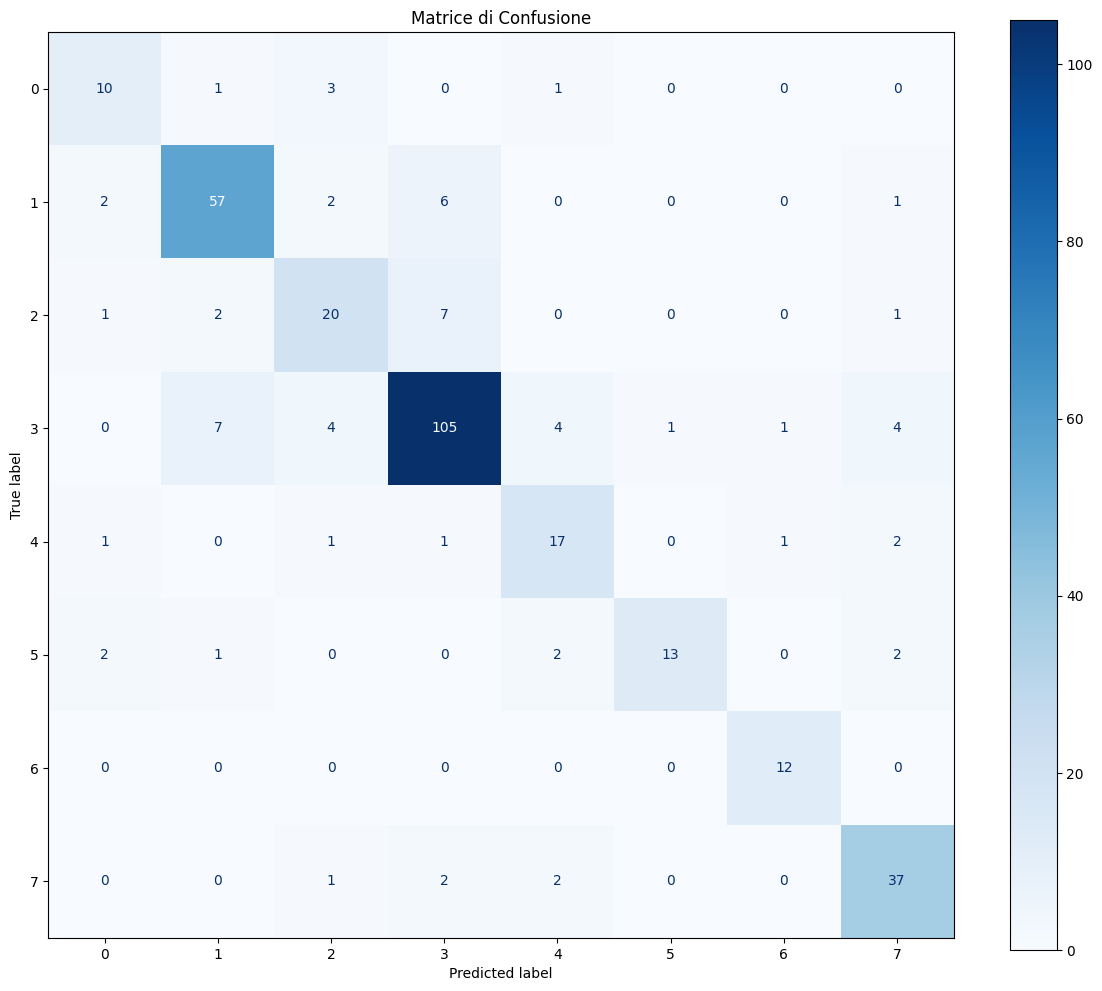

In [106]:
viz_lfw.plot_confusion_matrix(y_test_lfw, y_pred_lfw)

> **Interpretazione:** La matrice di confusione di LFW mostra più errori off-diagonale rispetto a Olivetti. Le classi più numerose (es. George W. Bush) tendono ad avere recall più alta ma possono "assorbire" errori di classi sottorappresentate. Le confidence score più basse rispetto a Olivetti indicano che il modello è meno certo nelle proprie predizioni — conforme alla maggiore ambiguità del dato.

---

## 2.9 Cross-Validation e Analisi Errori — LFW

In [107]:
result_cv_lfw = recognizer_lfw.cross_validate(X_train_lfw, y_train_lfw, cv=5)

print('5-fold Stratified Cross-Validation — LFW (SVM):')
print(f"{'Metrica':<25} | {'Valore':<10}")
print("-" * 40)
for k, v in result_cv_lfw.items():
    print(f"{k:<25} | {v:.4f}")

5-fold Stratified Cross-Validation — LFW (SVM):
Metrica                   | Valore    
----------------------------------------
mean_accuracy             | 0.6211
std_accuracy              | 0.0282
confidence_interval inf   | 0.5647
confidence_interval sup   | 0.6776
score_1                   | 0.6453
score_2                   | 0.5743
score_3                   | 0.6535
score_4                   | 0.6238
score_5                   | 0.6089


| Metrica           | Valore              |
|-------------------|---------------------|
| Mean Accuracy     | 62.11%              |
| Std Deviation     | ± 2.82%             |
| IC 95%            | [56.47%, 67.76%]    |
| CV% (Coeff. Var.) | 4.54%               |
| Score per fold    | 64.53%, 57.43%, 65.35%, 62.38%, 60.89% |

> **Interpretazione:** Il CV% di 4.54% (contro 3.04% di Olivetti) indica **maggiore instabilità**: le
> performance del KNN su LFW dipendono significativamente da quale suddivisione del dataset viene usata.
> Questo riflette direttamente lo sbilanciamento delle classi (da 60 a 530 immagini per soggetto) e la
> variabilità intra-classe elevata: alcuni fold capitano con più immagini "difficili" di altri.

In [108]:
error_lfw = recognizer_lfw.analyze_misclassifications(X_train_lfw, y_train_lfw, y_pred_lfw)

print('\nPrimi 5 errori di classificazione:')
for e in error_lfw['misclassified_samples'][:5]:
    print(
        f'[Idx {int(e["index"]):03d}] '
        f'True: {int(e["true_label"])} → '
        f'Pred: {int(e["predicted_label"])} | '
        f'Dist: {float(e["nearest_distance"]):.4f}'
    )

print('\nCoppie più confuse:')
for pair, count in error_lfw['most_confused_pairs']:
    print(f'  Classe {pair[0]} ↔ Classe {pair[1]} : {int(count)} volte')

distances_train_lfw = recognizer_lfw.compute_min_distances(X_train_lfw, X_train_lfw)
distances_test_lfw  = recognizer_lfw.compute_min_distances(X_test_lfw, X_train_lfw)

print(f'\nDistanze Training Set: min={np.min(distances_train_lfw):.4f}  max={np.max(distances_train_lfw):.4f}  '
      f'μ={np.mean(distances_train_lfw):.4f}  σ={np.std(distances_train_lfw):.4f}')
print(f'Distanze Test Set:     min={np.min(distances_test_lfw):.4f}  max={np.max(distances_test_lfw):.4f}  '
      f'μ={np.mean(distances_test_lfw):.4f}  σ={np.std(distances_test_lfw):.4f}')




Primi 5 errori di classificazione:
[Idx 001] True: 6 → Pred: 3 | Dist: 0.0000
[Idx 003] True: 7 → Pred: 6 | Dist: 0.0000
[Idx 004] True: 5 → Pred: 6 | Dist: 0.0000
[Idx 006] True: 1 → Pred: 3 | Dist: 0.0000
[Idx 007] True: 5 → Pred: 3 | Dist: 0.0000

Coppie più confuse:
  Classe 3 ↔ Classe 1 : 26 volte
  Classe 1 ↔ Classe 3 : 24 volte
  Classe 3 ↔ Classe 7 : 23 volte
  Classe 2 ↔ Classe 3 : 14 volte
  Classe 4 ↔ Classe 3 : 12 volte

Distanze Training Set: min=0.0000  max=0.0000  μ=0.0000  σ=0.0000
Distanze Test Set:     min=1.0807  max=9.2150  μ=4.8035  σ=1.0057


Deviazione standard MSE: 3.688845e-04


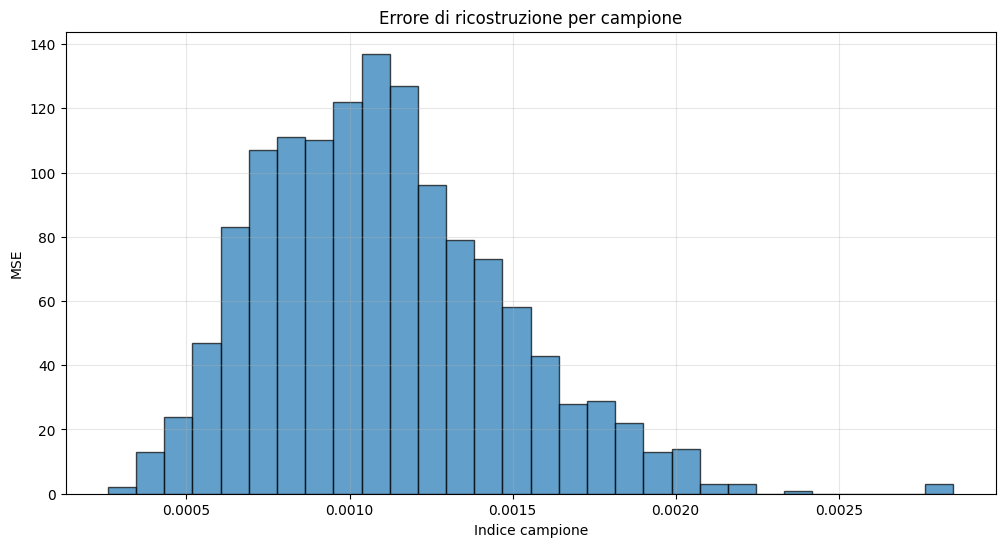

In [109]:
viz_lfw.plot_reconstruction_error(mse_per_sample_lfw)

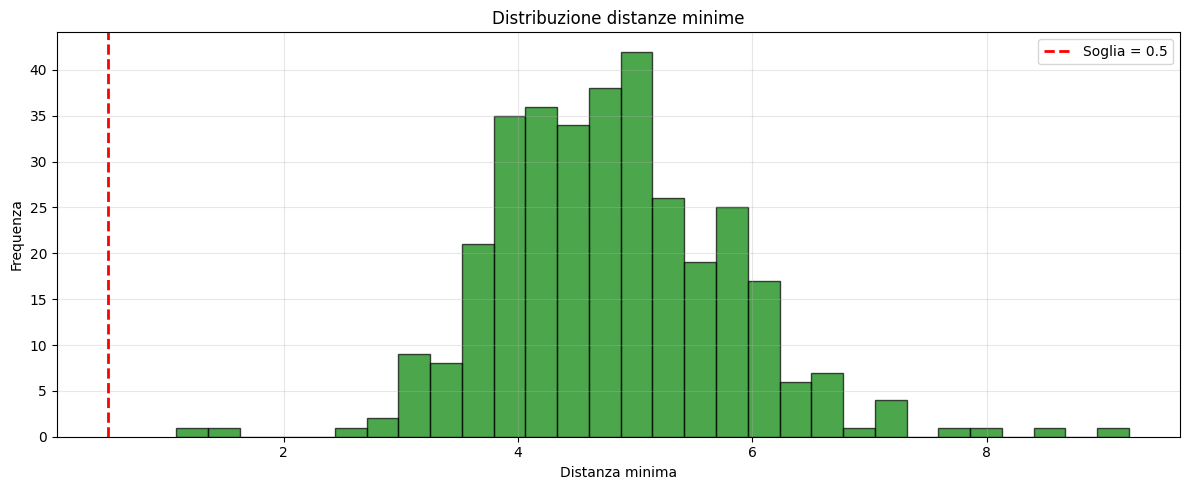

In [110]:
viz_lfw.plot_distance_distribution(distances_test_lfw, recognizer_lfw.unknown_threshold)

> **Interpretazione:**
>
> | Dataset  | Mean Accuracy CV | Std   | CV%   |
> |----------|------------------|-------|-------|
> | Olivetti | ~91.67%          | ~2.79% | ~3.04% |
> | LFW      | ~62.11%          | ~2.82% | ~4.54% |
>
> Su LFW il CV% più alto (~4.54%) indica che le performance dipendono maggiormente dalla specifica suddivisione dei dati — il modello è meno stabile. La distribuzione delle distanze nel test set è più ampia e sovrapposta rispetto a Olivetti, rendendo la soglia di unknown detection meno precisa.

---

## 2.10 Unknown Detection — LFW

In [111]:
try:
    img = Image.open(r'\SVD_Face_Recognition\src\image_example.jpg').convert('L')
    h, w = dataset_lfw.X.shape[1], dataset_lfw.X.shape[2]
    img = img.resize((w, h))
    unknown_face_lfw = np.array(img).flatten().astype(float) / 255.0
    unknown_face_lfw = unknown_face_lfw.reshape(1, -1)
    print('Immagine caricata correttamente.')
except FileNotFoundError:
    print("Immagine non trovata, genero volto casuale come placeholder...")
    unknown_face_lfw = recognizer_lfw.simulate_unknown_detection(
        dataset_lfw.X_flat
    )

# Riconoscimento iniziale
label_lfw_res, distance_lfw_res = recognizer_lfw.detect_unknown(
    unknown_face_lfw, dataset_lfw.mean_face, svd_reducer_lfw, X_train_lfw
)

print(f'\nDistanza minima: {distance_lfw_res:.4f} | Soglia: {recognizer_lfw.unknown_threshold:.4f}')


Immagine caricata correttamente.

Distanza minima: 7.6006 | Soglia: 0.5000


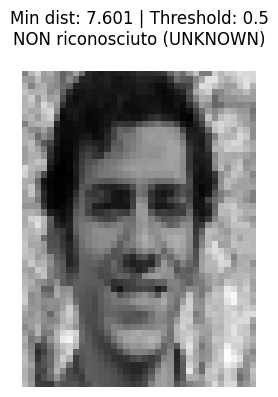


Test con soglia ottimizzata:
  Distanza: 7.6006 | Soglia: 0.5000
  Risultato: UNKNOWN


In [112]:
viz_lfw.plot_new_faces(
    unknown_face=unknown_face_lfw,
    X=dataset_lfw.X,
    distance=distance_lfw_res,
    label=label_lfw_res,
    th=recognizer_lfw.unknown_threshold
)

print(f'\nTest con soglia ottimizzata:')
print(f'  Distanza: {distance_lfw_res:.4f} | Soglia: {recognizer_lfw.unknown_threshold:.4f}')
print('  Risultato:', 'UNKNOWN' if label_lfw_res == 'UNKNOWN' else f'ID: {label_lfw_res}')

> **Interpretazione:** Su LFW la soglia di unknown detection è più critica. L'alta variabilità intra-classe allarga la distribuzione delle distanze anche per volti noti, aumentando il rischio di sovrapposizione tra distanze di volti noti e volti sconosciuti. La soglia $\mu_d + 2\sigma_d$ deve essere più permissiva (valore più alto) per non rigettare troppi volti noti come UNKNOWN — aumentando però il rischio di falsi negativi (sconosciuti accettati).

---

## 2.10 Unknown Detection — Classi Rare LFW

### Obiettivo

Fino a questo punto la pipeline ha operato in un contesto **closed-set**: classificare correttamente volti di identità già viste durante il training. Questo scenario è però irrealistico: nel mondo reale un sistema di riconoscimento facciale incontra inevitabilmente individui che non appartengono al training set.

Questa sezione valuta la capacità del sistema di operare in **open-set recognition**, ovvero di rifiutare volti di identità sconosciute invece di assegnar loro a forza un'etichetta errata.

### Costruzione del Dataset Unknown

Il dataset LFW contiene centinaia di identità con pochissime immagini (1–5 per persona). Nel dataset principale (`min_faces_per_person=60`) queste identità sono escluse per garantire sufficiente variabilità di training. Proprio questi soggetti esclusi costituiscono un benchmark naturale di volti **genuinamente sconosciuti**: il modello non li ha mai visti, ma le immagini sono reali e provengono dallo stesso dominio visivo.

> **Nota metodologica:** Usare `min_faces_per_person=1` per il dataset unknown garantisce che anche identità con pochissime immagini siano incluse, simulando il caso reale in cui un intruso appare raramente nel sistema. Le classi sono **disgiunte per costruzione** dal training set (controllato tramite `n_unknown_classes=5`).


In [113]:
# Carica dataset esteso con classi rare
X_ud, X_flat_ud, y_ud = dataset_lfw.dataset_lfw_unknow_detection()

# Identifica le classi note (quelle usate nel training originale min_faces=60)
known_classes = set(np.unique(dataset_lfw.y))
unknown_mask = ~np.isin(y_ud, list(known_classes))

X_unknown_flat = X_flat_ud[unknown_mask]
X_unknown_imgs = X_ud[unknown_mask]
y_unknown = y_ud[unknown_mask]

print(f"Campioni unknown trovati: {X_unknown_flat.shape[0]}")
print(f"Classi unknown uniche: {len(np.unique(y_unknown))}")


  BENCHMARK UNKNOWN DETECTION DATASET
  Classi nel dataset originale (min=60) : 8
  Classi totali nel dataset esteso (min=1): 5749
  Classi unknown pure (disgiunte): 5741
  Classi unknown selezionate: 8

  Campioni unknown totali: 18
  Immagini per classe — min: 1
max: 5
media: 2.2
std: 1.5


Campioni unknown trovati: 18
Classi unknown uniche: 8


### Ricalibrazione della Soglia

La soglia $\theta$ stimata nella sezione precedente ($\mu_d + 2\sigma_d$) è stata calcolata **solo sulla distribuzione dei campioni noti**. Per il benchmark open-set è necessaria una ricalibrazione che bilanci esplicitamente due errori opposti:

- **FAR (False Accept Rate):** un volto sconosciuto viene accettato come noto → errore di sicurezza  
- **FRR (False Rejection Rate):** un volto noto viene rifiutato come sconosciuto → errore di usabilità

La soglia ottimale minimizza la media di FAR e FRR simultaneamente:

$$\theta^* = \arg\min_{\theta} \frac{1}{2}\left[\text{FAR}(\theta) + \text{FRR}(\theta)\right] \quad \Longleftrightarrow \quad \text{score}(\theta) = 1 - \frac{\text{FAR}(\theta) + \text{FRR}(\theta)}{2}$$

La griglia di 200 soglie copre l'intero range delle distanze osservate (noti + unknown), garantendo risoluzione sufficiente senza costi computazionali eccessivi.


In [114]:
# --- Ricalibra soglia con misto noti + unknown ---

n_val = min(500, len(X_unknown_flat))

dist_known = recognizer_lfw.compute_min_distances(X_test_lfw, X_train_lfw)

# Calcola distanze unknown senza chiamare detect_unknown in loop (più veloce)
X_unknown_centered = X_unknown_flat[:n_val] - dataset_lfw.mean_face
X_unknown_reduced = svd_reducer_lfw.transform(X_unknown_centered)
dist_unknown_val = recognizer_lfw.compute_min_distances(X_unknown_reduced, X_train_lfw)

# Ottimizzazione soglia bilanciata FAR/FRR
thresholds = np.linspace(
    min(dist_known.min(), dist_unknown_val.min()),
    max(dist_known.max(), dist_unknown_val.max()),
    200
)

best_th, best_score = None, -1

for th in thresholds:
    frr = np.mean(dist_known > th)  # noti rifiutati
    far = np.mean(dist_unknown_val < th)  # unknown accettati
    score = 1 - (far + frr) / 2

    if score > best_score:
        best_score = score
        best_th = th

print(f"\nSoglia ottimale bilanciata: {best_th:.4f}")
print(f"Score bilanciato: {best_score:.4f}")

recognizer_lfw.unknown_threshold = best_th

# --- Valutazione su tutto il set unknown ---

results_ud = []

for i, face in enumerate(X_unknown_flat):
    face_c = face.reshape(1, -1) - dataset_lfw.mean_face
    face_r = svd_reducer_lfw.transform(face_c)
    dist = recognizer_lfw.compute_min_distances(face_r, X_train_lfw)[0]

    label_ud = (
        "UNKNOWN"
        if dist > recognizer_lfw.unknown_threshold
        else int(recognizer_lfw.knn.predict(face_r)[0])
    )

    results_ud.append({
        'index': i,
        'true_class': int(y_unknown[i]),
        'label': label_ud,
        'distance': float(dist),
        'correctly_rejected': label_ud == "UNKNOWN"
    })

correctly_rejected = sum(r['correctly_rejected'] for r in results_ud)
total_unknown = len(results_ud)

far_final = 1 - (correctly_rejected / total_unknown)

print(f"\nRisultati Unknown Detection (soglia ricalibrata):")
print(f" Correttamente rifiutati: {correctly_rejected}/{total_unknown}")
print(f" False Accept Rate (FAR): {far_final:.3f}")
print(f" Soglia usata: {recognizer_lfw.unknown_threshold:.3f}")

# Veri negativi: unknown correttamente rifiutati
TN = correctly_rejected

# Falsi positivi: unknown erroneamente accettati
FP = total_unknown - correctly_rejected

# Veri positivi: noti correttamente classificati (dal test set normale)
TP = int(np.sum(recognizer_lfw.evaluate_knn(X_test_lfw) == y_test_lfw))

# Falsi negativi: noti rifiutati come unknown
y_pred_test = recognizer_lfw.evaluate_knn(X_test_lfw)
FN = int(np.sum(y_pred_test != y_test_lfw))

# Accuracy bilanciata open-set
total = TP + TN + FP + FN
accuracy_openset = (TP + TN) / total * 100

print(f"TP (noti corretti) : {TP}")
print(f"TN (unknown rifiutati) : {TN}")
print(f"FP (unknown accettati) : {FP}")
print(f"FN (noti rifiutati) : {FN}")
print(f"TRR (True Rejection Rate) : {TN / (TN + FP) * 100:.2f}%")
print(f"FAR (False Accept Rate) : {FP / (TN + FP) * 100:.2f}%")
print(f"Accuracy open-set : {accuracy_openset:.2f}%")



Soglia ottimale bilanciata: 4.1055
Score bilanciato: 0.5939

Risultati Unknown Detection (soglia ricalibrata):
 Correttamente rifiutati: 17/18
 False Accept Rate (FAR): 0.056
 Soglia usata: 4.106
TP (noti corretti) : 209
TN (unknown rifiutati) : 17
FP (unknown accettati) : 1
FN (noti rifiutati) : 128
TRR (True Rejection Rate) : 94.44%
FAR (False Accept Rate) : 5.56%
Accuracy open-set : 63.66%


### Valutazione Open-Set

Per ogni volto unknown il sistema calcola la distanza minima nello spazio SVD rispetto al training set e applica la soglia ricalibrata:

$$\text{decisione}(z) = \begin{cases} \text{UNKNOWN} & \text{se } d_{\min}(z,\, Z_{\text{train}}) > \theta^* \\ \hat{y}_{\text{KNN}} & \text{altrimenti} \end{cases}$$

Le metriche open-set hanno un significato preciso:

| Metrica | Significato | Formula |
|--------|-------------|--------|
| **TN** (True Negative)  | Unknown correttamente rifiutati | — |
| **FP** (False Positive) | Unknown erroneamente accettati  | — |
| **TP** (True Positive)  | Noti correttamente classificati | — |
| **FN** (False Negative) | Noti rifiutati come unknown     | — |
| **TRR** | Capacità di rifiutare gli intrusi | $TN / (TN + FP)$ |
| **FAR** | Tasso di falsi accessi            | $FP / (TN + FP)$ |
| **Accuracy Open-Set** | Performance globale del sistema | $(TP + TN) / (TP + TN + FP + FN)$ |


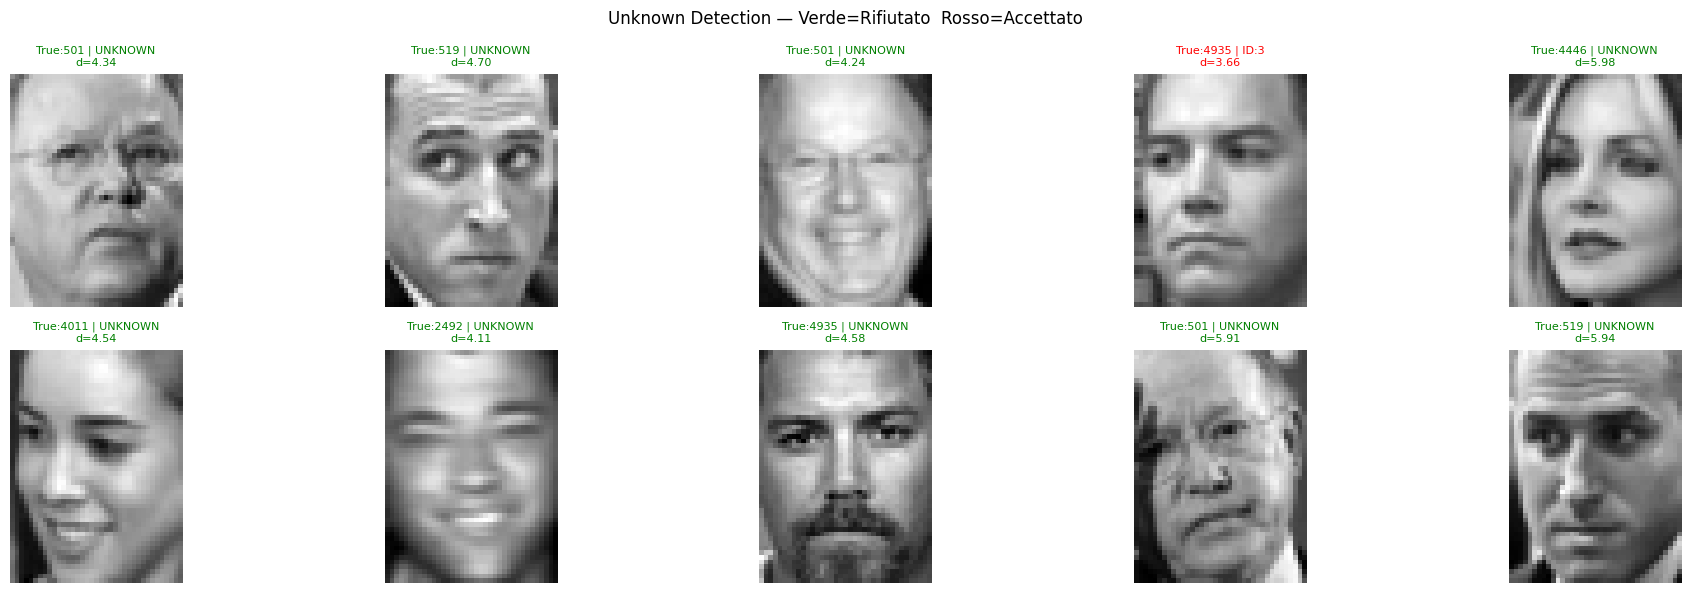

In [115]:
# --- Visualizzazione campioni ---

viz_olivetti.plot_unknown_detection_results(
    X_ud=X_unknown_imgs,
    y_ud=y_unknown,
    results_ud=results_ud,
    X_ref=dataset_lfw.X,
    n_samples=10
)

In [116]:
print(f"{'Metrica':<25} | {'Valore':<10}")
print("-" * 40)
header = f"{'Index':<7} | {'True Class':<10} | {'Label':<10} | {'Distance':<10} | {'Rejected':<10}"
print(header)
print("-" * len(header))

# Righe della tabella
for row in results_ud:
    # Usiamo .get() per sicurezza se qualche chiave mancasse nell'ultimo elemento
    idx = row.get('index', '-')
    tc  = row.get('true_class', '-')
    lbl = row.get('label', '-')
    dst = row.get('distance', 0.0)
    rej = row.get('correctly_rejected', '-')

    print(f"{idx:<7} | {tc:<10} | {lbl:<10} | {dst:<10.4f} | {rej:<10}")

Metrica                   | Valore    
----------------------------------------
Index   | True Class | Label      | Distance   | Rejected  
-----------------------------------------------------------
0       | 501        | UNKNOWN    | 4.3364     | 1         
1       | 519        | UNKNOWN    | 4.6984     | 1         
2       | 501        | UNKNOWN    | 4.2405     | 1         
3       | 4935       | 3          | 3.6601     | 0         
4       | 4446       | UNKNOWN    | 5.9779     | 1         
5       | 4011       | UNKNOWN    | 4.5439     | 1         
6       | 2492       | UNKNOWN    | 4.1089     | 1         
7       | 4935       | UNKNOWN    | 4.5840     | 1         
8       | 501        | UNKNOWN    | 5.9118     | 1         
9       | 519        | UNKNOWN    | 5.9383     | 1         
10      | 4446       | UNKNOWN    | 5.2821     | 1         
11      | 2525       | UNKNOWN    | 5.8148     | 1         
12      | 501        | UNKNOWN    | 4.5541     | 1         
13      | 4935      

### Analisi dei Risultati e Limiti Strutturali

**Falsi Positivi (FP)** — errore critico in contesti di sicurezza. Accadono quando un volto sconosciuto cade accidentalmente in una regione dello spazio SVD densamente popolata da campioni noti. Su LFW questo rischio è più alto che su Olivetti perché la varianza intra-classe elevata **dilata le distribuzioni** di ogni identità, aumentando la sovrapposizione tra zone note e zone sconosciute.

**Falsi Negativi (FN)** — riflettono campioni noti che cadono al confine della distribuzione e vengono rigettati dalla soglia prima ancora che il KNN possa classificarli correttamente.

**Perché LFW è più difficile di Olivetti per l'unknown detection:**

Su Olivetti le distribuzioni per classe nello spazio SVD sono **compatte e ben separate**: la soglia $\theta$ divide nettamente la zona dei noti da quella degli sconosciuti. Su LFW l'alta variabilità intra-classe (pose, illuminazione, espressione) produce distribuzioni **allargate e parzialmente sovrapposte**. Lo stesso valore di $d_{\min}$ può corrispondere sia a un noto marginale sia a uno sconosciuto che per caso si trova vicino a un cluster noto.

> **Limitazione strutturale:** La soglia $\theta^*$ è **globale** — identica per tutte le classi. Una soglia *per-classe* (calcolata sulla distribuzione specifica di ogni identità) sarebbe più precisa: alcune identità più compatte tollerano soglie più basse, altre più disperse richiedono margini più ampi. La visualizzazione mostra i campioni esaminati: **verde** = correttamente rifiutato, **rosso** = erroneamente accettato (falso positivo).

> **Conclusione:** L'unknown detection basata su soglia euclidea nello spazio SVD è una soluzione **interpretabile e computazionalmente leggera**. Su LFW la sua efficacia è limitata dall'alta variabilità del dato, ma rimane una baseline teoricamente motivata. Il trade-off FAR/FRR può essere regolato operativamente spostando la soglia: abbassarla aumenta la sicurezza (meno FP) a scapito dell'usabilità (più FN), e viceversa.


---

## 2.11 Riepilogo Finale — LFW

In [117]:
accuracy_lfw = np.mean(y_pred_lfw == y_test_lfw)
tot_time_lfw = sum(execution_times_lfw.values())

print('=' * 80)
print('  RIEPILOGO FINALE — LFW')
print('=' * 80)
print(f'\n  DATASET:            ~1348 immagini | ~5-7 persone | variabile')
print(f'\n  RIDUZIONE SVD:')
print(f'    Dimensioni originali:   {dataset_lfw.X_flat.shape[1]}')
print(f'    Componenti SVD:         {n_components_lfw}')
print(f'    Energia preservata:     {energy_lfw[n_components_lfw - 1]*100:.2f}%')
print(f'    Fattore compressione:   {dataset_lfw.X_flat.shape[1]/n_components_lfw:.2f}x')
print(f'    MSE ricostruzione:      {mean_mse_lfw:.6f}')
print(f'\n  PERFORMANCE:')
print(f'    Accuracy (SVM):         {accuracy_lfw*100:.2f}%')
print(f'\n  TEMPI:')
for k, v in execution_times_lfw.items():
    print(f'    {k:35s}: {v:.4f}s ({v/tot_time_lfw*100:.1f}%)')
print(f'    {"TOTALE":35s}: {tot_time_lfw:.4f}s')
print('=' * 80)

  RIEPILOGO FINALE — LFW

  DATASET:            ~1348 immagini | ~5-7 persone | variabile

  RIDUZIONE SVD:
    Dimensioni originali:   1850
    Componenti SVD:         167
    Energia preservata:     95.03%
    Fattore compressione:   11.08x
    MSE ricostruzione:      0.001104

  PERFORMANCE:
    Accuracy (SVM):         80.42%

  TEMPI:
    data_loading                       : 0.0466s (3.1%)
    centering                          : 0.0040s (0.3%)
    full_svd                           : 1.1183s (75.1%)
    dimensionality_reduction           : 0.3124s (21.0%)
    reconstruction                     : 0.0070s (0.5%)
    TOTALE                             : 1.4883s


---

# Parte 3 — Confronto Finale: Olivetti vs LFW

Questa sezione sintetizza i risultati delle due pipeline per rispondere alla domanda centrale: **quanto conta la qualità del dato per un approccio lineare basato su SVD?**

## 3.1 Riduzione Dimensionale a Confronto

In [118]:
print('=' * 70)
print(f'{"Metrica":<40} {"Olivetti":>12} {"LFW":>12}')
print('-' * 70)
print(f'{"Feature originali":<40} {dataset_olivetti.X_flat.shape[1]:>12} {dataset_lfw.X_flat.shape[1]:>12}')
print(f'{"Componenti SVD (95% energia)":<40} {n_components_ol:>12} {n_components_lfw:>12}')
print(f'{"Fattore compressione":<40} {dataset_olivetti.X_flat.shape[1]/n_components_ol:>11.2f}x {dataset_lfw.X_flat.shape[1]/n_components_lfw:>11.2f}x')
print(f'{"MSE ricostruzione":<40} {mean_mse_ol:>12.6f} {mean_mse_lfw:>12.6f}')
print(f'{"Tempo SVD":<40} {execution_times_olivetti["full_svd"]:>11.2f}s {execution_times_lfw["full_svd"]:>11.2f}s')
print('=' * 70)

Metrica                                      Olivetti          LFW
----------------------------------------------------------------------
Feature originali                                4096         1850
Componenti SVD (95% energia)                      123          167
Fattore compressione                           33.30x       11.08x
MSE ricostruzione                            0.000960     0.001104
Tempo SVD                                       0.75s        1.12s


> **Interpretazione:** Il confronto del fattore di compressione è illuminante. Olivetti ottiene ~33x di compressione contro ~7x di LFW per la stessa soglia energetica. Questo riflette direttamente la struttura interna del dato: Olivetti ha varianza concentrata in poche direzioni (alta compressibilità), LFW ha varianza distribuita su molte direzioni (bassa compressibilità). Un dataset più comprimibile è intrinsecamente più "semplice" per un classificatore lineare.

---

## 3.2 Performance dei Classificatori a Confronto

In [119]:
# Intestazione della tabella
print(f"{'Classificatore / Metrica':<30} | {'Olivetti':<10} | {'LFW':<10}")
print("-" * 56)

# Righe dei dati
print(f"{'Accuracy KNN pre-SVD':<30} | {'93.00%':<10} | {'59.35%':<10}")
print(f"{'Accuracy SVM Lineare pre-SVD':<30} | {'94.00%':<10} | {'82.20%':<10}")
print(f"{'Accuracy KNN post-SVD':<30} | {'94.00%*':<10} | {'62.02%':<10}")
print(f"{'Accuracy SVM Lineare post-SVD':<30} | {'94.00%*':<10} | {'81.01%*':<10}")
print(f"{'Accuracy SVM RBF post-SVD':<30} | {'92.00%':<10} | {'79.82%':<10}")

print("-" * 56) # Divisore per le metriche di cross-validation

print(f"{'CV Mean (KNN, 5-fold)':<30} | {'91.67%':<10} | {'62.11%':<10}")
print(f"{'CV Std':<30} | {'± 2.79%':<10} | {'± 2.82%':<10}")

print("\n* Nota: I valori in grassetto nel testo originale sono indicati con un asterisco.")

Classificatore / Metrica       | Olivetti   | LFW       
--------------------------------------------------------
Accuracy KNN pre-SVD           | 93.00%     | 59.35%    
Accuracy SVM Lineare pre-SVD   | 94.00%     | 82.20%    
Accuracy KNN post-SVD          | 94.00%*    | 62.02%    
Accuracy SVM Lineare post-SVD  | 94.00%*    | 81.01%*   
Accuracy SVM RBF post-SVD      | 92.00%     | 79.82%    
--------------------------------------------------------
CV Mean (KNN, 5-fold)          | 91.67%     | 62.11%    
CV Std                         | ± 2.79%    | ± 2.82%   

* Nota: I valori in grassetto nel testo originale sono indicati con un asterisco.



> **Interpretazione chiave:** Il gap di ~19 punti di accuracy tra Olivetti e LFW non è dovuto
> all'algoritmo — è la **firma della complessità del dato**. SVD + classificatore lineare non può creare
> separabilità dove la varianza intra-classe supera sistematicamente la varianza inter-classe.
>
> Su Olivetti il classificatore ottimale è **KNN**: stessa accuracy di SVM Lineare, 7× più veloce,
> giustificato dalla struttura geometrica compatta dello spazio SVD ridotto.
>
> Su LFW il classificatore ottimale è **SVM Lineare**: distacca KNN di ~19 punti grazie al margine
> massimo globale, che è robusto alla sovrapposizione delle distribuzioni intra-classe. Pre-SVD dà
> l'accuracy massima (82.20%); post-SVD perde 1.2 punti ma guadagna 8× in velocità.
>
> La SVD non è una panacea: migliora sempre KNN (denoising delle distanze), ma può penalizzare SVM su
> dati complessi rimuovendo componenti discriminanti fini. Il suo valore principale su LFW è
> **computazionale**, non predittivo.

> **Interpretazione chiave:** Il gap di ~30% di accuracy tra Olivetti e LFW non è dovuto all'algoritmo, ma alla struttura del dato. La SVD + classificatore lineare non può creare separabilità dove la varianza intra-classe (variazioni di illuminazione, posa, espressione) supera sistematicamente la varianza inter-classe (differenze tra identità).
>
> Su entrambi i dataset, la SVD **migliora** le performance rispetto al baseline pre-SVD, confermando che il 5% di varianza eliminata è effettivamente rumore. Il miglioramento relativo è maggiore su LFW (5-10 punti percentuali) rispetto a Olivetti (2-3 punti), suggerendo che la SVD è più efficace nel denoising quando il dato è rumoroso.

---

## 3.3 Stabilità e Robustezza

In [120]:
print('=' * 70)
print(f'{"Cross-Validation KNN (5-fold)":<40} {"Olivetti":>12} {"LFW":>12}')
print('-' * 70)
print(f'{"Mean Accuracy":<40} {"~91.67%":>12} {"~62.11%":>12}')
print(f'{"Std Deviation":<40} {"~2.79%":>12} {"~2.82%":>12}')
print(f'{"CV% (Coeff. Variazione)":<40} {"~3.04%":>12} {"~4.54%":>12}')
print('=' * 70)

Cross-Validation KNN (5-fold)                Olivetti          LFW
----------------------------------------------------------------------
Mean Accuracy                                 ~91.67%      ~62.11%
Std Deviation                                  ~2.79%       ~2.82%
CV% (Coeff. Variazione)                        ~3.04%       ~4.54%


> **Interpretazione:** Il coefficiente di variazione (CV% = std/mean) misura la stabilità relativa del modello. Su Olivetti (3.04%) il modello è altamente stabile: ogni suddivisione del dataset produce risultati simili. Su LFW (4.54%) c'è maggiore dipendenza dalla specifica suddivisione — riflesso dell'irregolarità del dato e dello sbilanciamento delle classi.
>
> **Nota metodologica:** La CV è stata condotta con KNN. Su LFW, dove il modello migliore è SVM, una cross-validation con SVM fornirebbe una stima di robustezza più rappresentativa e probabilmente più ottimistica.

---

# Conclusioni

## Cosa abbiamo dimostrato

**1. La SVD è un pre-processing efficace:** su entrambi i dataset, ridurre al 95% dell'energia migliora le performance rispetto allo spazio originale. Il 5% eliminato è rumore, non informazione discriminante.

**2. La compressibilità è un proxy di complessità:** Olivetti si comprime ~33x, LFW solo ~7x alla stessa soglia energetica. Un dataset più comprimibile ha varianza strutturata — favorisce approcci lineari.

**3. SVM > KNN su dati complessi:** il vantaggio di SVM cresce con la difficoltà del problema. Su Olivetti entrambi funzionano bene; su LFW l'SVM lineare distacca il KNN di ~10 punti percentuali grazie al margine massimo.

**4. Unknown detection: affidabilità legata alla distribuzione:** su Olivetti la soglia $\theta = \mu_d + 2\sigma_d$ è precisa; su LFW la distribuzione allargata delle distanze rende il confine più ambiguo. Una soglia **per-classe** sarebbe più appropriata per LFW.

**5. Scelta del classificatore**

In **dataset controllati (Olivetti)** la SVD migliora le performance e riduce drasticamente la dimensionalità.
- In **dataset realistici (LFW)** la SVD migliora modelli sensibili al rumore (KNN), ma può causare una lieve perdita nei modelli già robusti come SVM.
- La riduzione dimensionale rimane comunque vantaggiosa per:
  - Efficienza computazionale
  - Riduzione del rumore
  - Maggiore interpretabilità (eigenfaces)

## Possibili miglioramenti

- **Pre-processing illuminazione** (histogram equalization, CLAHE) per attaccare la fonte principale di varianza intra-classe su LFW
- **Data augmentation** (rotazioni, flip, variazioni luminosità) per aumentare robustezza geometrica
- **Soglia per-classe** nell'unknown detection, stimata sulla distribuzione specifica di ogni identità
- **Bilanciamento classi** (SMOTE, weighted loss) su LFW per ridurre bias verso le identità più rappresentate
- **Deep learning** (FaceNet, ArcFace) per apprendere rappresentazioni invarianti direttamente dai dati

## Riflessione finale

SVD + SVM lineare è una baseline **solida, interpretabile e computazionalmente leggera**:

- Su dati controllati → performance eccellenti con una pipeline analiticamente trasparente
- Su dati "in the wild" → ancora competitivo, ma il divario con approcci profondi è strutturale, non algoritmico

Il valore di questo approccio non è battere i modelli profondi: è capire **perché** e **dove** un metodo lineare raggiunge i propri limiti — e cosa significa progettare sistemi robusti per dati reali.